# Data set and Problem


ชุดข้อมูลเหตุความรุนแรงในครอบครัว (Domestic Violence Incidents in Thailand)

Dataset Description

ชุดข้อมูลนี้เป็นข้อมูลจากกรมกิจการสตรีและสถาบันครอบครัว เป็นข้อมูลเกี่ยวกับ เหตุความรุนแรงในครอบครัว ที่มีการแจ้งเหตุและบันทึกข้อมูลจากหน่วยงานที่เกี่ยวข้อง โดยครอบคลุมรายละเอียดของเหตุการณ์ พื้นที่เกิดเหตุ ข้อมูลผู้กระทำ และข้อมูลผู้ถูกกระทำความรุนแรง


ข้อมูลถูกจัดแบ่งออกเป็น 3 ตารางหลัก ได้แก่

![](1.png)
![](2.png)
![](3.png)


แหล่งที่มา	ข้อมูลจากฐานข้อมูลรายงานการให้ความช่วยเหลือผู้ถูกกระทำด้วยความรุนแรงในครอบครัว

ฝ่ายงาน	กองส่งเสริมสถาบันครอบครัว

### ประเด็นคำถามสำหรับการวิเคราะห์ข้อมูล ###


👥 ข้อ 1 — ใครเสี่ยงที่สุด? (Who is at risk?)
📊 จากข้อมูลเกี่ยวกับ ผู้ถูกกระทำความรุนแรง และ ผู้กระทำความรุนแรงในครอบครัว

จงสร้างกราฟหรือ Visualization ที่ช่วยให้ผู้อ่านสามารถมองเห็นได้อย่างชัดเจนว่า

    กลุ่มอายุใด
    เพศใด

มี ความเสี่ยงสูงที่สุดในแต่ละบทบาท และรูปแบบความเสี่ยงของ ผู้กระทำและผู้ถูกกระทำมีความแตกต่างกันอย่างไร

Visualization ควรช่วยให้ผู้อ่านสามารถ เปรียบเทียบโครงสร้างของทั้งสองกลุ่มได้ในภาพเดียว และสามารถมองเห็น pattern ของความเสี่ยงได้อย่างชัดเจน


📍⏰ ข้อ 2 — เกิดที่ไหน เมื่อไหร่? (Where & When?)
📊 จงสร้าง Visualization ที่แสดง รูปแบบการกระจายตัวของเหตุการณ์ความรุนแรงในครอบครัว

โดยพิจารณาทั้ง

    มิติของพื้นที่
    มิติของช่วงเวลา

เพื่อให้สามารถมองเห็นว่า เหตุการณ์เหล่านี้เกิดขึ้นที่ใดบ่อยที่สุด และเกิดขึ้นในช่วงเวลาใดมากที่สุด

ผลงานควรช่วยระบุให้เห็นว่า พื้นที่หรือช่วงเวลาใดคือ “จุดวิกฤต (Hotspot)”

ซึ่งอาจต้องได้รับ การจัดสรรทรัพยากร การเฝ้าระวัง หรือมาตรการป้องกันเพิ่มเติมจากหน่วยงานที่เกี่ยวข้อง


⚠️ ข้อ 3 — อะไรคือสัญญาณเตือน? (What triggers violence?)
📊 จากข้อมูลเกี่ยวกับ ปัจจัยเสี่ยงของผู้กระทำความรุนแรงในครอบครัว

จงสร้าง Visualization ที่ช่วยให้ผู้กำหนดนโยบายสามารถเข้าใจได้อย่างรวดเร็วว่า

    ปัจจัยใดควรได้รับความสำคัญในการป้องกันก่อน
    และ เหตุใดปัจจัยนั้นจึงมีความสำคัญต่อการเกิดเหตุความรุนแรง

ผลงานควรสามารถสื่อสารให้เห็น ลำดับความสำคัญของปัจจัยเสี่ยง และช่วยให้ผู้อ่านเข้าใจว่า
หากต้องออกแบบมาตรการป้องกัน ควรเริ่มต้นจากปัจจัยใดก่อน ผ่านการนำเสนอข้อมูลที่ชัดเจนและเข้าใจง่ายผ่าน Visualization 📊



# Setting import package and Data set

In [ ]:
#import package
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from geopandas.tools import geocode
from shapely.geometry import LineString
import numpy as np
import pandas as pd

In [55]:
import gdown

# List of Google Drive file IDs to download
file_ids = [
    '13f_dsmnZzwOz3GHDmSk5AwxovNyK4KsQ',
    '1YLbwMIdgdAPeSYE5edqtSTR0FBRRch9f',
    '1XfMioDavjyq2QuwqejMm27WGADcLuIwa',
    '1c2idc31t4k8-b4m76MhR0DElvC--7Vq6',
    '14QjxjfhI9aZ4_XA2yj-HaFBCG0hU0bjK',
    '1-aNJjExj8R9EHFAswKL5A2b2voGCCgqQ',
    '16-LS0jfpJJfRH-uSKJlwhe_0BcW4_F0s',
    '1Po7_uSy1jBUCSi6fvXX7vcjiyaSNsAV0',
    '1dyZut_lC7-3YWha70XzqjxnLwDgXUxWY'
]

# Download each file individually
for file_id in file_ids:
    print(f"Downloading file with ID: {file_id}")
    # Use the 'id' parameter for direct file ID download
    # Add --fuzzy to handle potential redirects or permission issues more gracefully
    !gdown --id "{file_id}" --fuzzy

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13f_dsmnZzwOz3GHDmSk5AwxovNyK4KsQ
To: /content/thsarabunnew-webfont.ttf
100% 98.3k/98.3k [00:00<00:00, 98.4MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1YLbwMIdgdAPeSYE5edqtSTR0FBRRch9f
To: /content/ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv
100% 330k/330k [00:00<00:00, 135MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings

In [ ]:
# ─── ดาวน์โหลดและตั้งค่า Font TH Sarabun New ───
#!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style='whitegrid', font='TH Sarabun New')
mpl.rcParams['font.family'] = 'TH Sarabun New'
mpl.rcParams['axes.unicode_minus'] = False


In [ ]:
#Data set from "https://www.thackle.or.th/th/dataset/84"
#Data set of province.csv form "https://www.thackle.or.th/th/datatset/83"

#import file into Data frame
incidents_df = pd.read_csv("ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv")
perpetrators_df = pd.read_csv("ข้อมูลผู้กระทำความรุนแรงในครอบครัว.csv")
victims_df = pd.read_csv("ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว.csv")

#Data Thailand map from "https://data.opendevelopmentmekong.net/th/dataset/8f3fa1b8-cb5c-48c8-9fd7-d3c213ea23db/resource/1559cee4-fedc-4330-be9c-d8cf3dd75015/download/tha_admbnda_adm1_rtsd_20190221.zip"
#import shapefile already have geometry polygon
Thailandmap=gpd.read_file("tha_admbnda_adm1_rtsd_20190221/tha_admbnda_adm1_rtsd_20190221.shp")


# Explore Data set

In [ ]:
#Example incident data
incidents_df

#ข้อมูลมี 877 rows × 11 columns

,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,18:01 – 00:00,สถานที่ส่วนบุคคล
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,00:01 – 06:00,สถานที่ส่วนบุคคล
...,...,...,...,...,...,...,...,...,...,...,...
872,ภาคใต้,สุราษฎร์ธานี,ไชยา,เลม็ด,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,อื่นๆ (ระบุ),ศูนย์กู้ภัยไชยา,ข่าว,06:01 – 12:00,สถานที่ส่วนบุคคล
873,ภาคใต้,สุราษฎร์ธานี,กาญจนดิษฐ์,ท่าทองใหม่,VCIS (Incident ถูกสร้างจากระบบ VCIS),บุคคล,ผู้รับทราบเหตุการณ์และนำมาแจ้งต่อ,ไม่ระบุ,โทรศัพท์,12:01 – 18:00,สถานที่ส่วนบุคคล
874,ภาคใต้,สุราษฎร์ธานี,คีรีรัฐนิคม,ถ้ำสิงขร,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,18:01 – 00:00,สถานที่ส่วนบุคคล
875,ภาคใต้,สุราษฎร์ธานี,คีรีรัฐนิคม,ย่านยาว,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,12:01 – 18:00,สถานที่สาธารณะ


In [ ]:
#check Null Data in Incidents Data frame
incidents_df.isnull().sum()

,0
Regional,0
Province,0
District,0
Sub-District,0
Derivation,0
Source,0
Source Type,0
Other Source Type,0
Channel,0
Period,0


In [ ]:
# show all posible of data in all columms in incidents_df
for columns in incidents_df.columns :
    print(columns , incidents_df[columns].unique())

Regional ['ภาคกลาง' 'ภาคตะวันออกเฉียงเหนือ' 'ภาคเหนือ' 'ภาคใต้']
Province ['กรุงเทพมหานคร' 'กาญจนบุรี' 'จันทบุรี' 'ฉะเชิงเทรา' 'ชลบุรี' 'ชัยนาท'
 'ตราด' 'นครนายก' 'นครปฐม' 'นนทบุรี' 'ปทุมธานี' 'ประจวบคีรีขันธ์'
 'ปราจีนบุรี' 'พระนครศรีอยุธยา' 'ระยอง' 'ราชบุรี' 'ลพบุรี' 'สมุทรปราการ'
 'สมุทรสงคราม' 'สมุทรสาคร' 'สระบุรี' 'สระแก้ว' 'สิงห์บุรี' 'สุพรรณบุรี'
 'อ่างทอง' 'เพชรบุรี' 'กาฬสินธุ์' 'ขอนแก่น' 'ชัยภูมิ' 'นครพนม'
 'นครราชสีมา' 'บึงกาฬ' 'บุรีรัมย์' 'มหาสารคาม' 'มุกดาหาร' 'ยโสธร'
 'ร้อยเอ็ด' 'ศรีสะเกษ' 'สกลนคร' 'สุรินทร์' 'หนองคาย' 'อุดรธานี'
 'อุบลราชธานี' 'เลย' 'กำแพงเพชร' 'ตาก' 'นครสวรรค์' 'น่าน' 'พะเยา' 'พิจิตร'
 'พิษณุโลก' 'ลำปาง' 'ลำพูน' 'อุตรดิตถ์' 'อุทัยธานี' 'เชียงราย' 'เชียงใหม่'
 'เพชรบูรณ์' 'แพร่' 'แม่ฮ่องสอน' 'กระบี่' 'ชุมพร' 'ตรัง' 'นครศรีธรรมราช'
 'นราธิวาส' 'ปัตตานี' 'พังงา' 'พัทลุง' 'ภูเก็ต' 'ยะลา' 'ระนอง' 'สงขลา'
 'สตูล' 'สุราษฎร์ธานี']
District ['เขตหนองจอก' 'เขตบางแค' 'เขตทวีวัฒนา' 'เขตบางซื่อ' 'เขตประเวศ'
 'เขตคลองเตย' 'เขตคลองสามวา' 'เขตบางเขน' 'เขตทุ่งครุ' 'เขตดุ

In [ ]:
# example of perpetrators data
victims_df

#ข้อมูลมี 564 rows × 19 columns

,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,18,วัยรุ่น 13 - 18 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ยาย
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,36,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,พี่น้อง/ลูกพี่ลูกน้อง
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,ชาย,78,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,บุตร
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,หญิง,64,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,จดทะเบียนหย่า,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,"คู่ชีวิต,สามี"
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,หญิง,35,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ใช่,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,ภรรยา"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,ภาคใต้,สตูล,ละงู,กำแพง,ชาย,55,วัยกลางคน 36 - 59 ปี,สมรส,จดทะเบียนสมรสแล้ว,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ใช่,ไม่,บุตร
593,ภาคใต้,สตูล,เมืองสตูล,พิมาน,หญิง,30,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,ภรรยา"
594,ภาคใต้,สุราษฎร์ธานี,วิภาวดี,ตะกุกเหนือ,หญิง,25,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ไม่ระบุ,ไม่,ใช่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,สามี"
595,ภาคใต้,สุราษฎร์ธานี,เมืองสุราษฎร์ธานี,มะขามเตี้ย,หญิง,38,วัยกลางคน 36 - 59 ปี,แยกกันอยู่,จดทะเบียนหย่า,ใช่,ใช่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,อดีตสามี"


In [ ]:
#check Null Data in perpetrators Data frame
victims_df.isnull().sum()

,0
Regional,0
Province,0
District,0
Sub-District,0
Gender,0
Age,0
Age Range,0
Relation,0
Mariage Registration,0
Alcohol,0


In [ ]:
# show all posible of data in all columms in perpetrators_df
for columns in victims_df.columns :
    print(columns , victims_df[columns].unique())

Regional ['ภาคกลาง' 'ภาคตะวันออกเฉียงเหนือ' 'ภาคเหนือ' 'ภาคใต้']
Province ['กรุงเทพมหานคร' 'กาญจนบุรี' 'จันทบุรี' 'ฉะเชิงเทรา' 'ชลบุรี' 'ชัยนาท'
 'ตราด' 'นครนายก' 'นนทบุรี' 'ปทุมธานี' 'ประจวบคีรีขันธ์' 'ปราจีนบุรี'
 'พระนครศรีอยุธยา' 'ระยอง' 'ราชบุรี' 'ลพบุรี' 'สมุทรปราการ' 'สมุทรสงคราม'
 'สมุทรสาคร' 'สระบุรี' 'สระแก้ว' 'สิงห์บุรี' 'สุพรรณบุรี' 'อ่างทอง'
 'เพชรบุรี' 'กาฬสินธุ์' 'ขอนแก่น' 'ชัยภูมิ' 'นครพนม' 'นครราชสีมา' 'บึงกาฬ'
 'บุรีรัมย์' 'มหาสารคาม' 'มุกดาหาร' 'ยโสธร' 'ร้อยเอ็ด' 'ศรีสะเกษ' 'สกลนคร'
 'สุรินทร์' 'หนองคาย' 'อุดรธานี' 'อุบลราชธานี' 'เลย' 'กำแพงเพชร' 'ตาก'
 'นครสวรรค์' 'น่าน' 'พะเยา' 'พิจิตร' 'พิษณุโลก' 'อุตรดิตถ์' 'อุทัยธานี'
 'เชียงราย' 'เพชรบูรณ์' 'แพร่' 'แม่ฮ่องสอน' 'กระบี่' 'ชุมพร'
 'นครศรีธรรมราช' 'นราธิวาส' 'ปัตตานี' 'พังงา' 'พัทลุง' 'ภูเก็ต' 'ยะลา'
 'ระนอง' 'สงขลา' 'สตูล' 'สุราษฎร์ธานี']
District ['เขตหนองจอก' 'เขตบางแค' 'เขตทวีวัฒนา' 'เขตบางซื่อ' 'เขตประเวศ'
 'เขตคลองเตย' 'เขตคลองสามวา' 'เขตบางเขน' 'เขตทุ่งครุ' 'เขตดุสิต'
 'เขตมีนบุรี' 'เขตภาษีเจริญ' 'เขตสะพานสู

In [ ]:
# example of victims data
perpetrators_df

#ข้อมูลมี 597 rows × 20 columns

,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,61,วัยสูงอายุ 60 ปีขึ้นไป,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,26,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,หญิง,55,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,หญิง,64,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,จดทะเบียนหย่า,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,ชาย,33,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,ภาคใต้,สตูล,ละงู,กำแพง,ชาย,25,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ใช่,ไม่
560,ภาคใต้,สตูล,เมืองสตูล,พิมาน,ชาย,47,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
561,ภาคใต้,สุราษฎร์ธานี,วิภาวดี,ตะกุกเหนือ,ชาย,39,วัยกลางคน 36 - 59 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ใช่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่
562,ภาคใต้,สุราษฎร์ธานี,เมืองสุราษฎร์ธานี,มะขามเตี้ย,ชาย,40,วัยกลางคน 36 - 59 ปี,แยกกันอยู่,จดทะเบียนหย่า,ใช่,ใช่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่


In [ ]:
#check Null Data in victims Data frame
perpetrators_df.isnull().sum()

,0
Regional,0
Province,0
District,0
Sub-District,0
Gender,0
Age,0
Age Range,0
Relation,0
Mariage Registration,0
Alcohol,0


In [ ]:
# show all posible of data in all columms in perpetrators_df
for columns in perpetrators_df.columns :
    print(columns , perpetrators_df[columns].unique())

Regional ['ภาคกลาง' 'ภาคตะวันออกเฉียงเหนือ' 'ภาคเหนือ' 'ภาคใต้']
Province ['กรุงเทพมหานคร' 'กาญจนบุรี' 'จันทบุรี' 'ฉะเชิงเทรา' 'ชลบุรี' 'ชัยนาท'
 'ตราด' 'นครนายก' 'นนทบุรี' 'ปทุมธานี' 'ประจวบคีรีขันธ์' 'ปราจีนบุรี'
 'พระนครศรีอยุธยา' 'ระยอง' 'ราชบุรี' 'ลพบุรี' 'สมุทรปราการ' 'สมุทรสงคราม'
 'สมุทรสาคร' 'สระบุรี' 'สระแก้ว' 'สิงห์บุรี' 'สุพรรณบุรี' 'อ่างทอง'
 'เพชรบุรี' 'กาฬสินธุ์' 'ขอนแก่น' 'ชัยภูมิ' 'นครพนม' 'นครราชสีมา' 'บึงกาฬ'
 'บุรีรัมย์' 'มหาสารคาม' 'มุกดาหาร' 'ยโสธร' 'ร้อยเอ็ด' 'ศรีสะเกษ' 'สกลนคร'
 'สุรินทร์' 'หนองคาย' 'อุดรธานี' 'อุบลราชธานี' 'เลย' 'กำแพงเพชร' 'ตาก'
 'นครสวรรค์' 'น่าน' 'พะเยา' 'พิจิตร' 'พิษณุโลก' 'อุตรดิตถ์' 'อุทัยธานี'
 'เชียงราย' 'เพชรบูรณ์' 'แพร่' 'แม่ฮ่องสอน' 'กระบี่' 'ชุมพร'
 'นครศรีธรรมราช' 'นราธิวาส' 'ปัตตานี' 'พังงา' 'พัทลุง' 'ภูเก็ต' 'ยะลา'
 'ระนอง' 'สงขลา' 'สตูล' 'สุราษฎร์ธานี']
District ['เขตหนองจอก' 'เขตบางแค' 'เขตทวีวัฒนา' 'เขตบางซื่อ' 'เขตประเวศ'
 'เขตคลองเตย' 'เขตคลองสามวา' 'เขตบางเขน' 'เขตทุ่งครุ' 'เขตดุสิต'
 'เขตมีนบุรี' 'เขตภาษีเจริญ' 'เขตสะพานสู

Since there are no null values in the dataset, I will skip the data imputation process.

# Basic Analysis and Visualization

## วิเคราะห์ผู้ถูกกระทำ

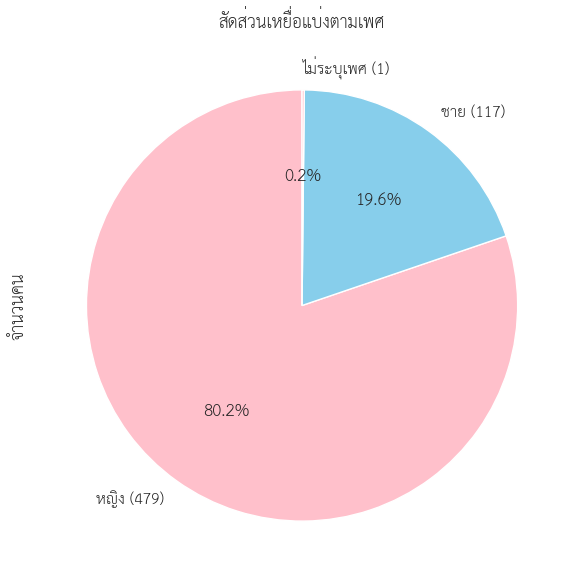

In [ ]:
# Calculate the frequency of Gender
frequency_gender = victims_df["Gender"].value_counts()

# Create new labels that include the count: "Name (Count)"
new_labels = [f'{label} ({count})' for label, count in zip(frequency_gender.index, frequency_gender.values)]

# Plot using these new labels
frequency_gender.plot.pie(
    labels=new_labels,     # Apply the custom labels here
    autopct='%1.1f%%',    # Keep the percentage inside
    figsize=(7, 7),
    colors=['pink','skyblue'],
    startangle= 90
)
plt.ylabel("จำนวนคน")
plt.title("สัดส่วนเหยื่อแบ่งตามเพศ")
plt.show()

80 % ของเหยื่อเป็นผู้หญิง

In [ ]:
print(victims_df["Age Range"].value_counts())

print("\n min age : " + str(victims_df["Age"].min())+ " year\n",
      "max age : " + str(victims_df["Age"].max())+ " year\n",
      "mean age : "+ str(victims_df["Age"].mean().round(2))+ " year"
)

Age Range
วัยกลางคน 36 - 59 ปี           175
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี    150
วัยสูงอายุ 60 ปีขึ้นไป         108
วัยรุ่น 13 - 18 ปี              75
วัยเด็กตอนกลาง 7 - 12 ปี        58
วัยเด็กเล็กแรกเกิด - 6 ปี       31
Name: count, dtype: int64

 min age : 2 year
 max age : 92 year
 mean age : 36.53 year


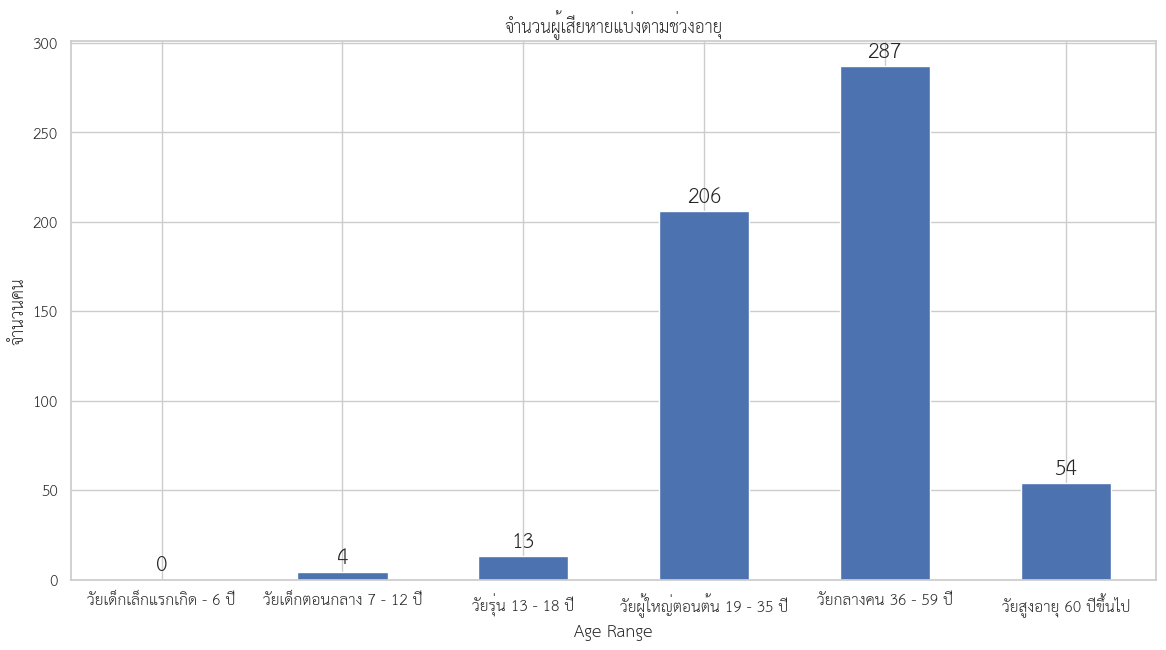

In [ ]:
# Define the logical order
order = [
    'วัยเด็กเล็กแรกเกิด - 6 ปี',
    'วัยเด็กตอนกลาง 7 - 12 ปี',
    'วัยรุ่น 13 - 18 ปี',
    'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี',
    'วัยกลางคน 36 - 59 ปี',
    'วัยสูงอายุ 60 ปีขึ้นไป'
]

# Reindex the counts to match this order
counts = perpetrators_df["Age Range"].value_counts().reindex(order)

# Plot
ax = counts.plot(kind='bar', figsize=(14, 7), rot=0)
ax.bar_label(ax.containers[0], padding=3, fontsize = 15)


plt.title("จำนวนผู้เสียหายแบ่งตามช่วงอายุ")
plt.ylabel("จำนวนคน")
plt.show()

จากข้อมูลเหยื่อส่วนใหญ่เป็นวัยกลางคน (36-59 ปี) โดยความเสี่ยงในการเกิดจะเพิ่มขึ้นตามอายุ

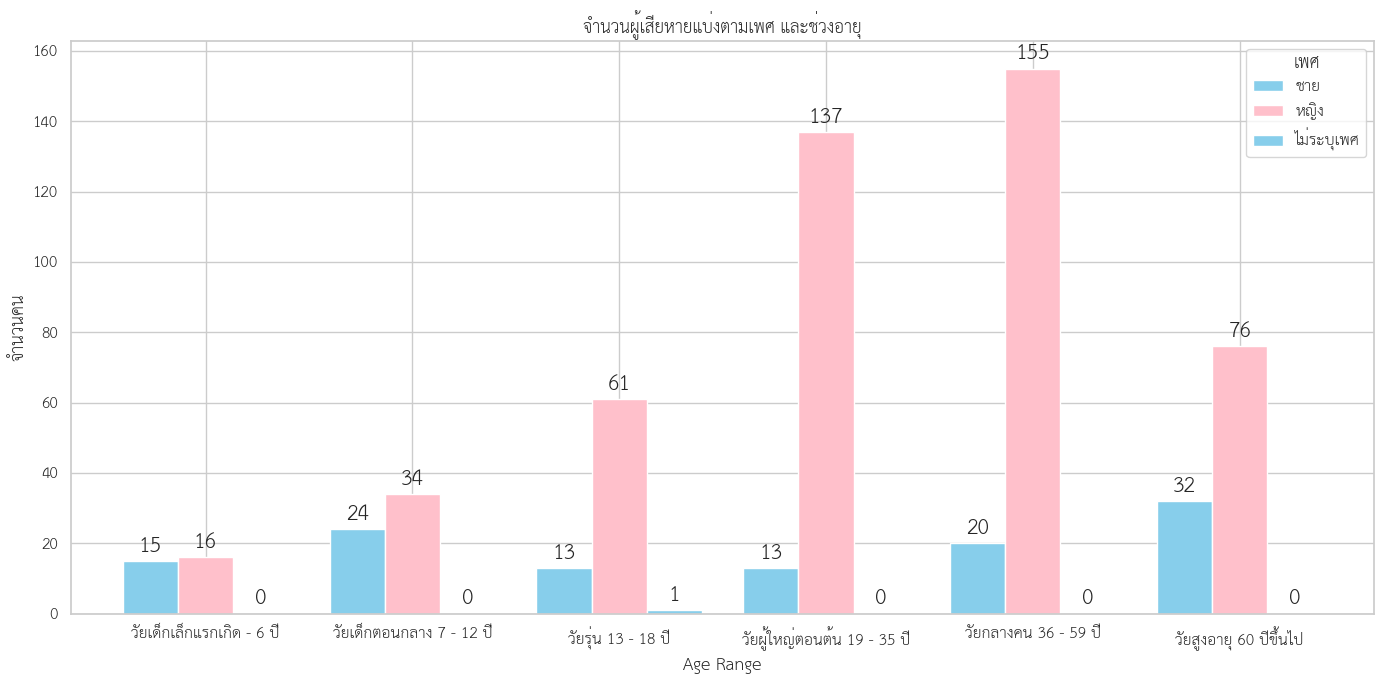

In [ ]:
# pivot_df
# Rows = Age Range
# Columns = Gender (ชาย, หญิง)
pivot_victims_df = victims_df.groupby(['Age Range', 'Gender']).size().unstack(fill_value=0)

#Reorder the index to match your specific age categories
pivot_victims_df = pivot_victims_df.reindex(order)

# Plot - pandas handles the side-by-side logic automatically
ax = pivot_victims_df.plot(kind='bar',
                   color=['skyblue', 'pink'],
                   figsize=(14, 7),
                   width=0.8,
                   rot=0)

# 4. Add numeric labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3,fontsize = 15)

#plot
plt.title("จำนวนผู้เสียหายแบ่งตามเพศ และช่วงอายุ")
plt.xlabel("Age Range")
plt.ylabel("จำนวนคน")
plt.legend(title="เพศ")
plt.tight_layout()
plt.show()

แยกตามเพศ ผู้หญิง ส่วนใหญ่เป็นวัยกลางคน (36-59 ปี) โดยความเสี่ยงในการเกิดจะเพิ่มขึ้นตามอายุ คล้ายการกระจายของข้อมูลเดิม เนื่องจากเป็นประชากรส่วนใหญ่ของข้อมูล

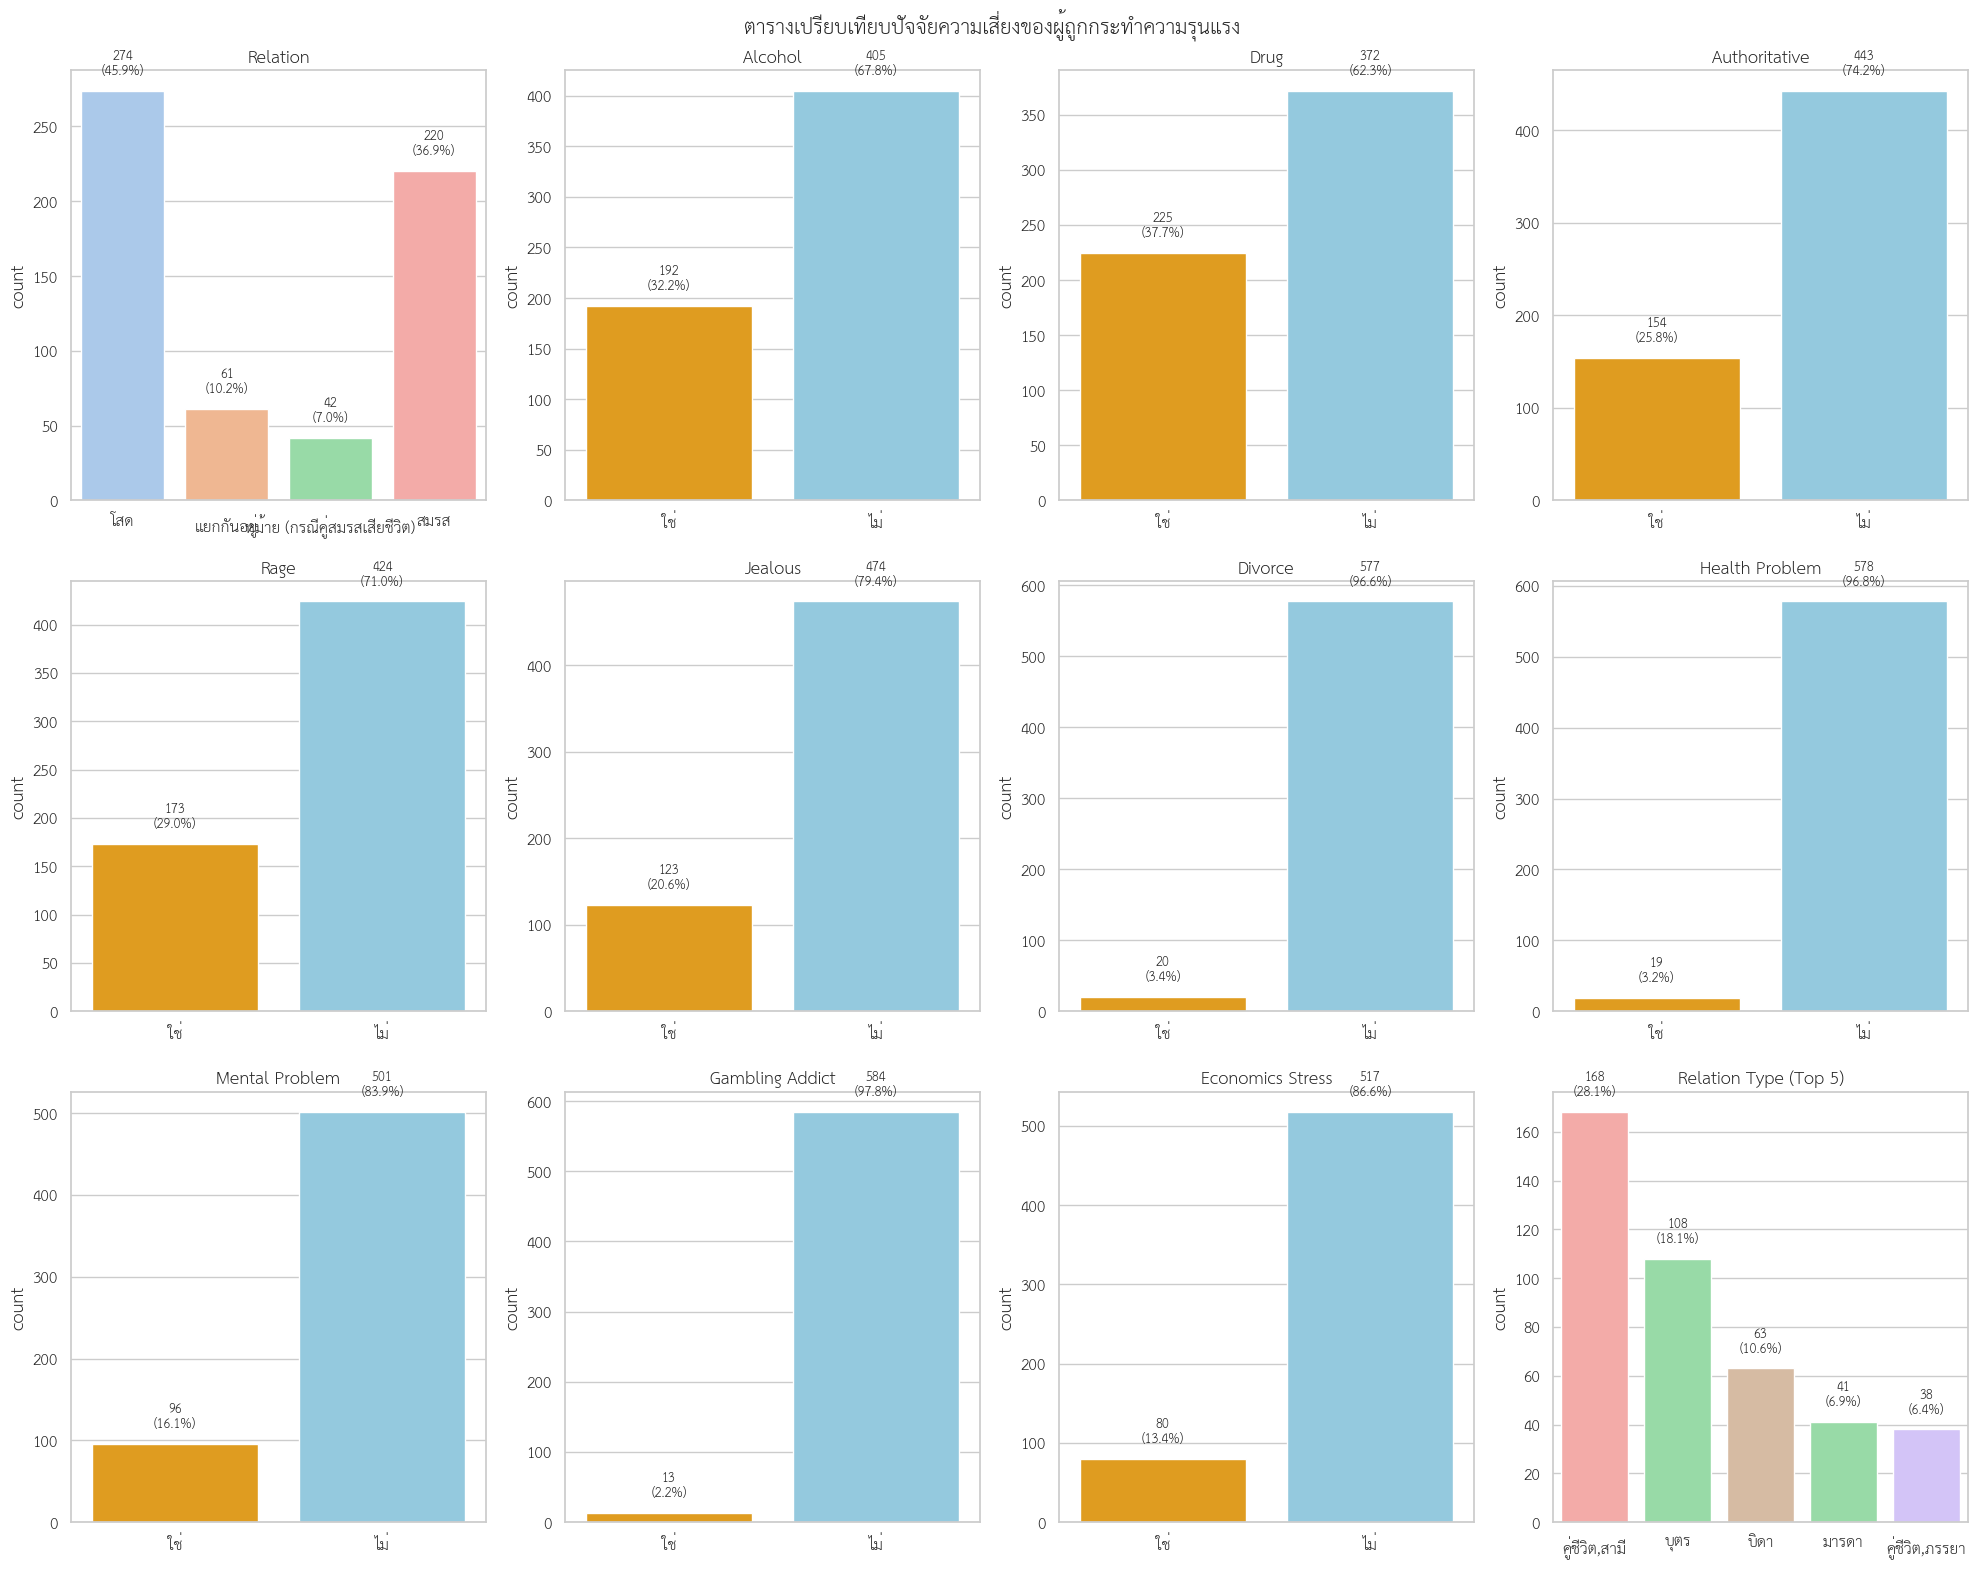

In [ ]:
risks = ["Relation",
        "Alcohol",
        "Drug",
        "Authoritative",
        "Rage",
        "Jealous",
        "Divorce",
        "Health Problem",
        "Mental Problem",
        "Gambling Addict",
        "Economics Stress",
        "Relation Type"]

# Define your custom color palette
# 'ใช่' (Yes) -> Orange, 'ไม่' (No) -> Blue/Grey
color_map = {"ใช่": "orange", "ไม่": "skyblue"}

# Define the grid (3 rows, 4 columns = 12 total slots)
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
axes = axes.flatten()  # Flatten to easily loop through 1D

# Iterate through your 11 risk factors
for i, factor in enumerate(risks):
    # Check if the column exists in your dataframe
    if factor == "Relation Type":
        top_5_order = victims_df[factor].value_counts().nlargest(5).index
        sns.countplot(x=victims_df[factor],
                    ax=axes[i],
                    palette="pastel",
                    hue=victims_df[factor],
                    order=top_5_order,
                    legend=False)
        axes[i].set_title(f"{factor} (Top 5)")

    elif factor == "Relation":
        sns.countplot(x=victims_df[factor],
                    ax=axes[i],
                    palette="pastel",
                    hue=victims_df[factor],
                    legend= False)
        axes[i].set_title(factor)

    else :
        sns.countplot(x=victims_df[factor],
                    ax=axes[i],
                    palette= color_map ,
                    hue=victims_df[factor],
                    order=["ใช่", "ไม่"],
                    legend= False)
        axes[i].set_title(factor)

    axes[i].set_xlabel('') # Clean up the x-axis label

    total = len(victims_df[factor])

    for container in axes[i].containers:
        # We create a custom list of strings: "Count (Percentage%)"
        labels = [f'{int(v.get_height())}\n({(v.get_height()/total)*100:.1f}%)' for v in container]

        # Pass these labels to bar_label
        axes[i].bar_label(container, labels=labels, padding=10, fontsize=9.)


plt.suptitle("ตารางเปรียบเทียบปัจจัยความเสี่ยงของผู้ถูกกระทำความรุนแรง")
plt.tight_layout()
plt.show()

จากการเปรียบเที่ยบปัจจัยเสี่ยงในกลุ่มของผู้ถูกกระทำ พบว่า แอลกอฮอล์ การใช้ยา การมีอิทธิพลมากกว่า ความโกรธ ความหึงหวง สามารถพบได้ในเหยื่อ > 25%

ในขณะที่ สถานะทางการเงิน และปัญหาสุขภาพจิต พบได้ 10-15 %


ความสัมพันธ์กับผู้กระทำส่วนใหญ่ เป็นคู่สามี

## วิเคราะห์ผู้กระทำ

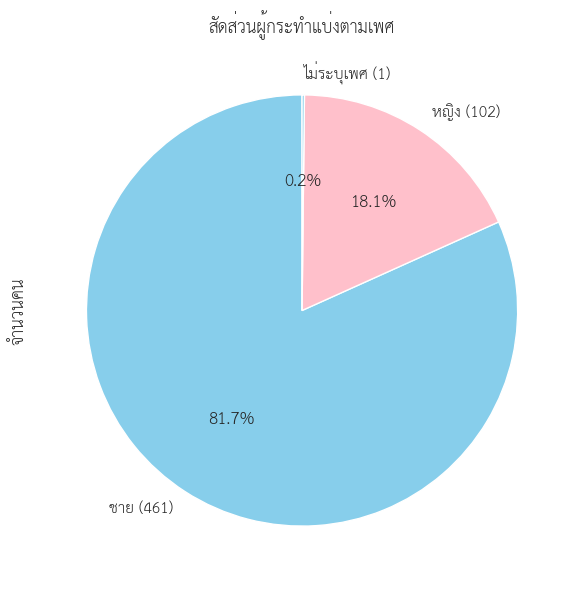

In [ ]:
# Calculate the frequency of Gender
frequency_gender = perpetrators_df["Gender"].value_counts()

# Create new labels that include the count: "Name (Count)"
new_labels = [f'{label} ({count})' for label, count in zip(frequency_gender.index, frequency_gender.values)]

# Plot using these new labels
frequency_gender.plot.pie(
    labels=new_labels,     # Apply the custom labels here
    autopct='%1.1f%%',    # Keep the percentage inside
    figsize=(7, 7),
    colors=['skyblue','pink'],
    startangle= 90
)
plt.ylabel("จำนวนคน")
plt.title("สัดส่วนผู้กระทำแบ่งตามเพศ")
plt.show()

80 % ของเหยื่อเป็นผู้ชาย

In [ ]:
print(perpetrators_df["Age Range"].value_counts())

print("\n min age : " + str(perpetrators_df["Age"].min())+ " year\n",
      "max age : " + str(perpetrators_df["Age"].max())+ " year\n",
      "mean age : "+ str(perpetrators_df["Age"].mean().round(2))+ " year"
)

Age Range
วัยกลางคน 36 - 59 ปี           287
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี    206
วัยสูงอายุ 60 ปีขึ้นไป          54
วัยรุ่น 13 - 18 ปี              13
วัยเด็กตอนกลาง 7 - 12 ปี         4
Name: count, dtype: int64

 min age : 10 year
 max age : 84 year
 mean age : 40.22 year


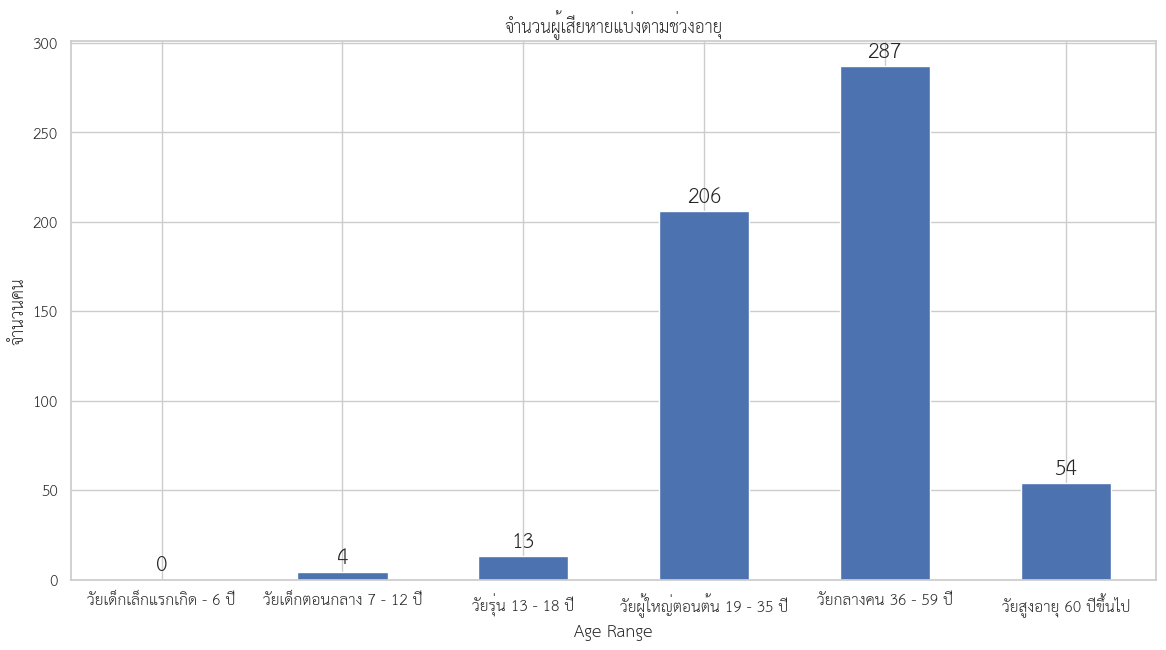

In [ ]:
# Reindex the counts to match this order
counts = perpetrators_df["Age Range"].value_counts().reindex(order)

# Plot
ax = counts.plot(kind='bar', figsize=(14, 7), rot=0)
ax.bar_label(ax.containers[0], padding=3,fontsize = 15)


plt.title("จำนวนผู้เสียหายแบ่งตามช่วงอายุ")
plt.ylabel("จำนวนคน")
plt.show()

จากข้อมูลผู้กระทำส่วนใหญ่เป็นวัยกลางคน (36-59 ปี) โดยความเสี่ยงในการเกิดจะเพิ่มขึ้นตามอายุ

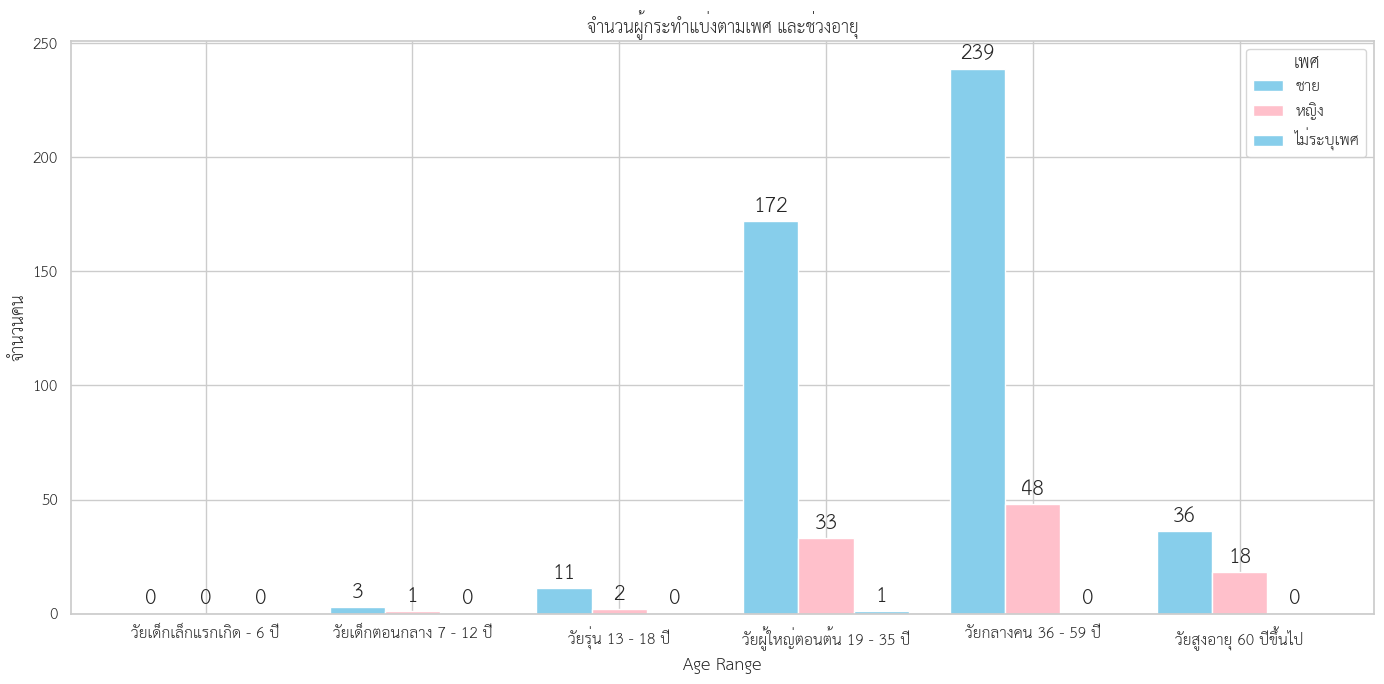

In [ ]:
# pivot_df
# Rows = Age Range
# Columns = Gender (ชาย, หญิง)
pivot_perpetrators_df = perpetrators_df.groupby(['Age Range', 'Gender']).size().unstack(fill_value=0)

#Reorder the index to match your specific age categories
pivot_perpetrators_df = pivot_perpetrators_df.reindex(order)

# Plot - pandas handles the side-by-side logic automatically
ax = pivot_perpetrators_df .plot(kind='bar',
                   color=['skyblue', 'pink'],
                   figsize=(14, 7),
                   width=0.8,
                   rot=0)

# 4. Add numeric labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3,fontsize= 15)

#plot
plt.title("จำนวนผู้กระทำแบ่งตามเพศ และช่วงอายุ")
plt.xlabel("Age Range")
plt.ylabel("จำนวนคน")
plt.legend(title="เพศ")
plt.tight_layout()
plt.show()

แยกตามเพศ ผู้ชาย ส่วนใหญ่เป็นวัยกลางคน (36-59 ปี) โดยความเสี่ยงในการเกิดจะเพิ่มขึ้นตามอายุ คล้ายการกระจายของข้อมูลเดิม เนื่องจากเป็นประชากรส่วนใหญ่ของข้อมูล

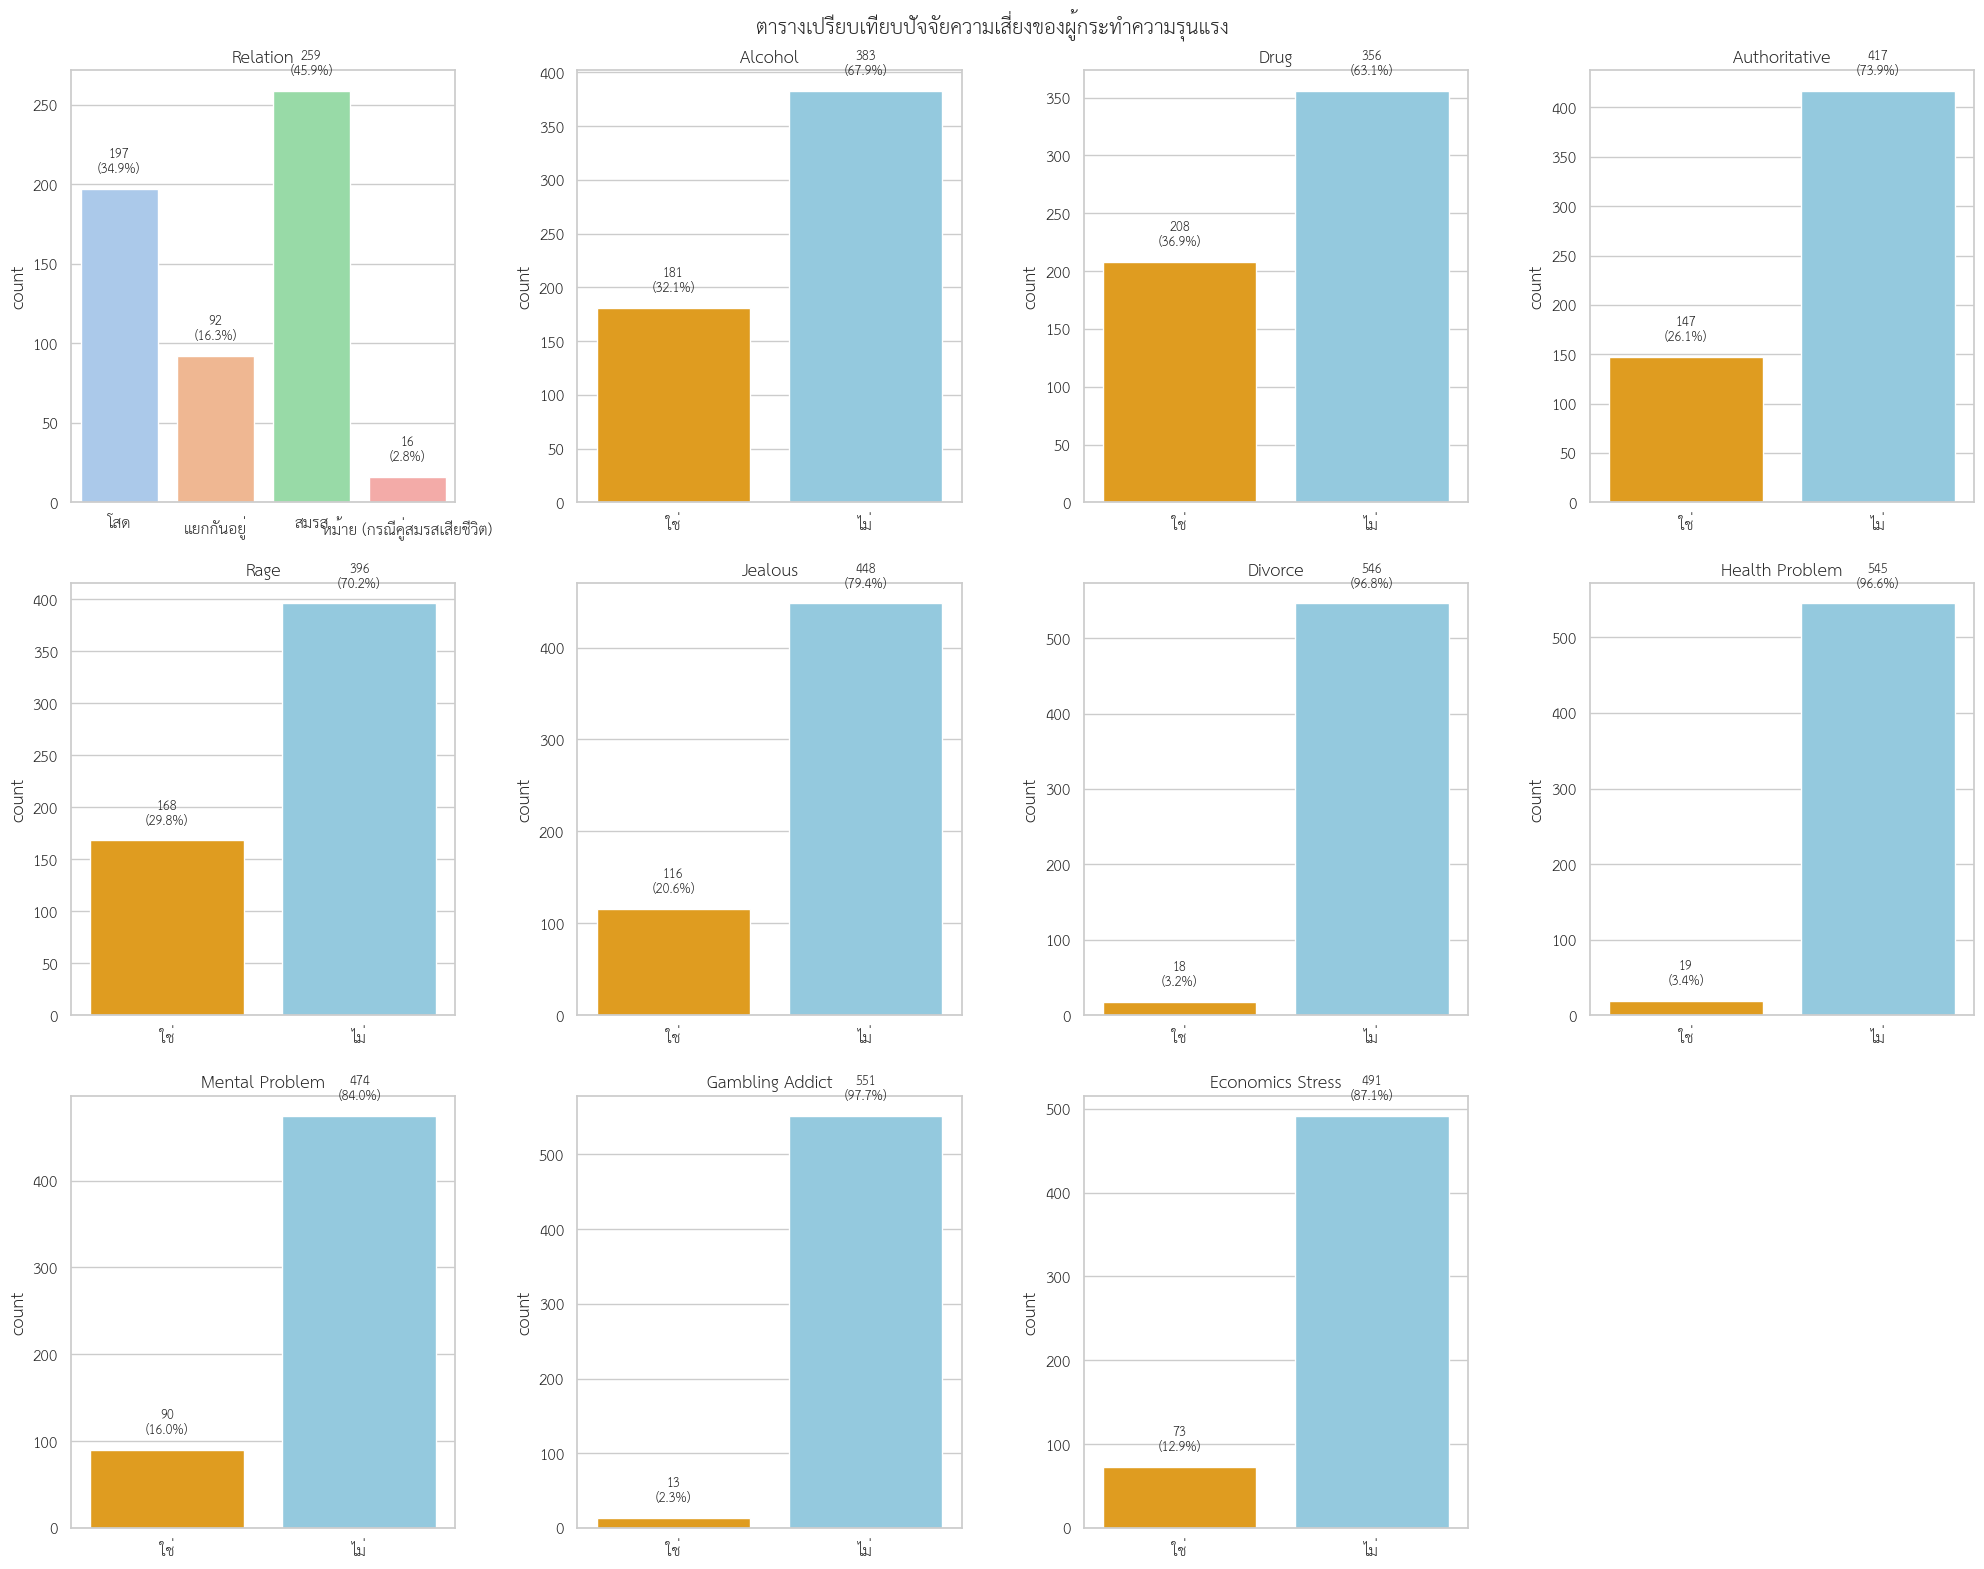

In [ ]:
risks = ["Relation",
        "Alcohol",
        "Drug",
        "Authoritative",
        "Rage",
        "Jealous",
        "Divorce",
        "Health Problem",
        "Mental Problem",
        "Gambling Addict",
        "Economics Stress"]

# Define the grid (3 rows, 4 columns = 12 total slots)
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
axes = axes.flatten()  # Flatten to easily loop through 1D

# Iterate through your 11 risk factors
for i, factor in enumerate(risks):
    # Check if the column exists in your dataframe
    if factor == "Relation":
        sns.countplot(x=perpetrators_df[factor],
                    ax=axes[i],
                    palette="pastel",
                    hue=perpetrators_df[factor],
                    legend= False)
        axes[i].set_title(factor)

    else :
        sns.countplot(x=perpetrators_df[factor],
                    ax=axes[i],
                    palette= color_map ,
                    hue=perpetrators_df[factor],
                    order=["ใช่", "ไม่"],
                    legend= False)
        axes[i].set_title(factor)

    axes[i].set_xlabel('') # Clean up the x-axis label

    total = len(perpetrators_df[factor])

    for container in axes[i].containers:
        # We create a custom list of strings: "Count (Percentage%)"
        labels = [f'{int(v.get_height())}\n({(v.get_height()/total)*100:.1f}%)' for v in container]

        # Pass these labels to bar_label
        axes[i].bar_label(container, labels=labels, padding=10, fontsize=9)

# hide last plot due to no data to show
axes[-1].set_axis_off()
plt.suptitle("ตารางเปรียบเทียบปัจจัยความเสี่ยงของผู้กระทำความรุนแรง")
plt.tight_layout()
plt.show()

ผู้กระทำส่วนใหญ่เป็นผู้ที่สมรสแล้ว

จากการเปรียบเที่ยบปัจจัยเสี่ยงในกลุ่มของผู้กระทำ พบว่า แอลกอฮอล์ การใช้ยา การมีอิทธิพลมากกว่า ความโกรธ ความหึงหวง สามารถพบได้ในเหยื่อ > 25%

ในขณะที่ สถานะทางการเงิน และปัญหาสุขภาพจิต พบได้ 10-15 %


ซึงคล้ายกับการเปรียบเทียบภายใน เมื่อเทียบกับผู้ถูกกระทำ

## สรุปข้อมูลผู้ถูกกระทำความรุนแรง และ ผู้กระทำความรุนแรงในครอบครัว

/tmp/ipykernel_5438/2587680353.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(abs(t)) for t in ticks])


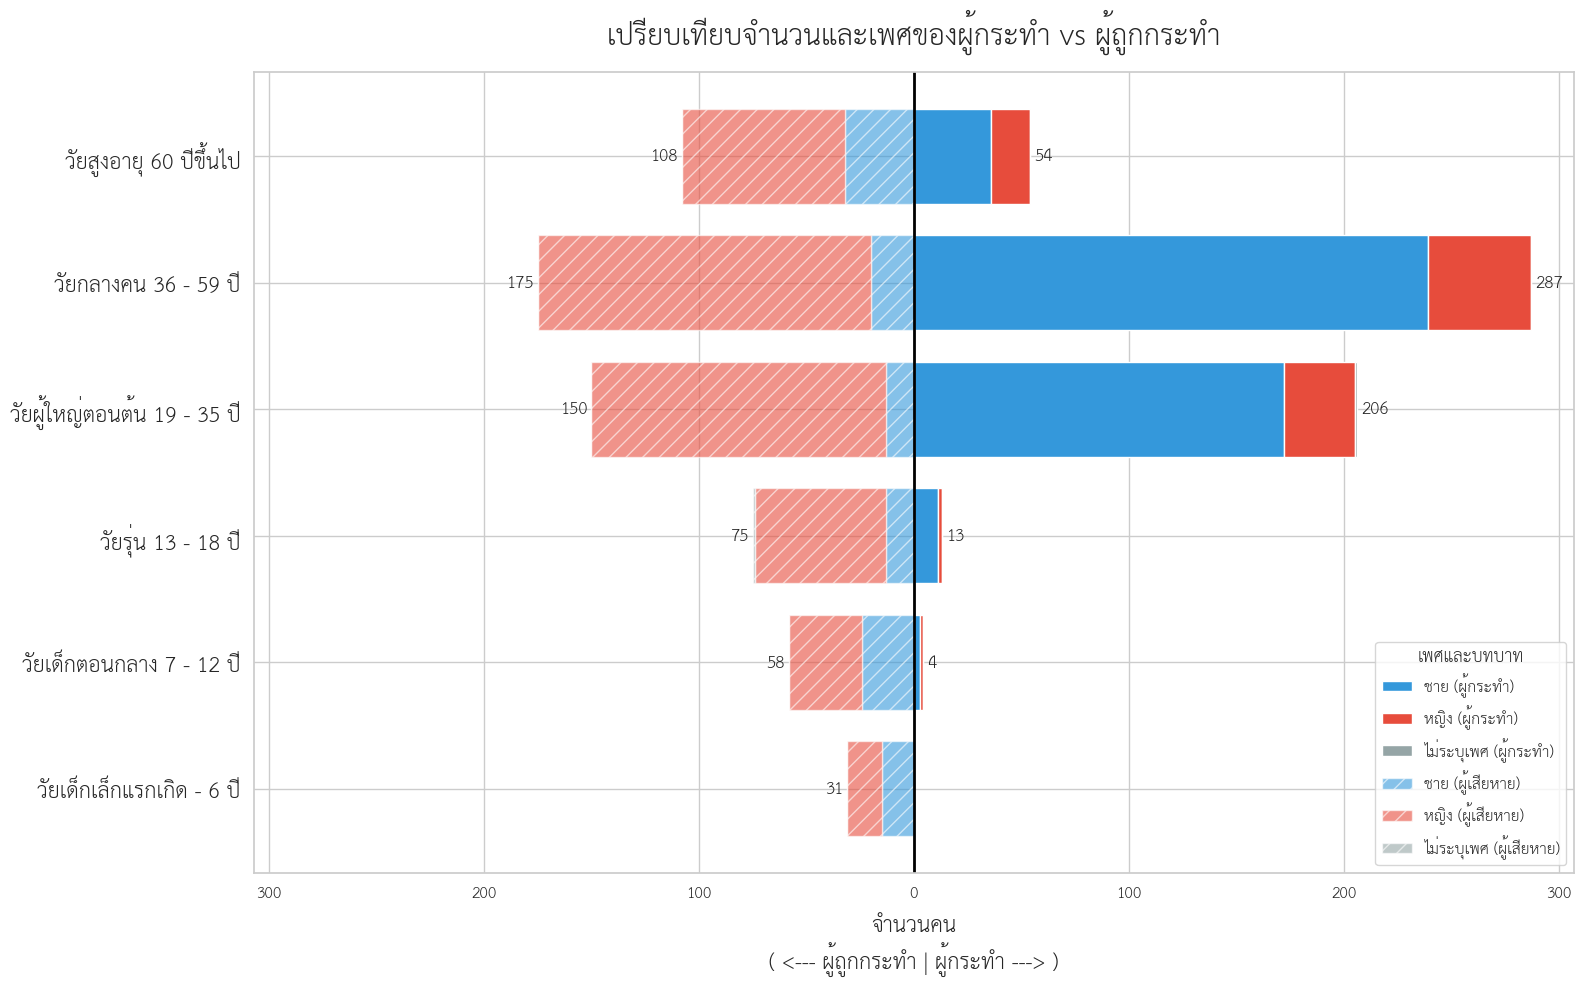

In [ ]:

# Ensure consistent columns
columns = ['ชาย', 'หญิง', 'ไม่ระบุเพศ']
pivot_perpetrators_df = pivot_perpetrators_df.reindex(columns=columns, fill_value=0)
pivot_victims_df = pivot_victims_df.reindex(columns=columns, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 10))
y = np.arange(len(order))
height = 0.75

# Colors: Solid for Perpetrators, Lighter/Hatched for Victims
colors = ['#3498db', '#e74c3c', '#95a5a6']

# Plot Perpetrators (Growing RIGHT)
left_perp = np.zeros(len(order))
for i, col in enumerate(columns):
    ax.barh(y, pivot_perpetrators_df[col], height, left=left_perp,
            label=f'{col} (ผู้กระทำ)', color=colors[i], edgecolor='white')
    left_perp += pivot_perpetrators_df[col].values

# Plot Victims (Growing LEFT)
left_vict = np.zeros(len(order))
for i, col in enumerate(columns):
    # Use negative values to grow left
    ax.barh(y, -pivot_victims_df[col], height, left=-left_vict,
            label=f'{col} (ผู้เสียหาย)', color=colors[i], alpha=0.6, hatch='//', edgecolor='white')
    left_vict += pivot_victims_df[col].values

# FIX RATIO (CENTERS THE 0-LINE)
# Use nanmax with a fallback to 0 to avoid NaN errors
p_max = np.nanmax(left_perp) if left_perp.size > 0 else 0
v_max = np.nanmax(left_vict) if left_vict.size > 0 else 0

# Determine the absolute maximum count
max_val = max(p_max, v_max)

# The limit must include the GAP and room for text labels
limit = max_val + 20

ax.set_xlim(-limit, limit)

# Add Total Labels at the ends of the bars
for i in range(len(order)):
    if left_perp[i] > 0:
        ax.text(left_perp[i] + 2, i, f'{int(left_perp[i])}', va='center')
    if left_vict[i] > 0:
        ax.text(-left_vict[i] - 2, i, f'{int(left_vict[i])}', va='center', ha='right')

# Styling & Formatting
ax.axvline(0, color='black', linewidth=2) # The vertical "Mirror" line
ax.set_yticks(y)
ax.set_yticklabels(order, fontsize=15)

# Make X-axis labels show absolute (positive) values
ticks = ax.get_xticks()
ax.set_xticklabels([int(abs(t)) for t in ticks])


plt.title("เปรียบเทียบจำนวนและเพศของผู้กระทำ vs ผู้ถูกกระทำ", fontsize=20, pad=20)

ax.text(0, -0.12, "จำนวนคน\n( <--- ผู้ถูกกระทำ | ผู้กระทำ ---> )",
        transform=ax.get_xaxis_transform(),
        ha='center', fontsize=15)

# Legend
plt.legend(loc='lower right', title="เพศและบทบาท")

plt.tight_layout()
plt.show()

> ถูกกระทำส่วนใหญ่เป็น ผู้หญิงช่วงอายุ วัยกลางคนและวัยผูัใหญ่ตอนต้นเป็นส่วนใหญ่

> ผู้กระทำส่วนใหญ่เป็น ผู้ชายช่วงอายุ โดยช่วงอายุใกล้เคียงกันทั้ง 2 ชุดข้อมูล

เนื่องจากความแตกต่างด้านจำนวนของสองกลุ่มประชากร จึงเปรียบเทียบเป็น % ของปัจจัยเสียง

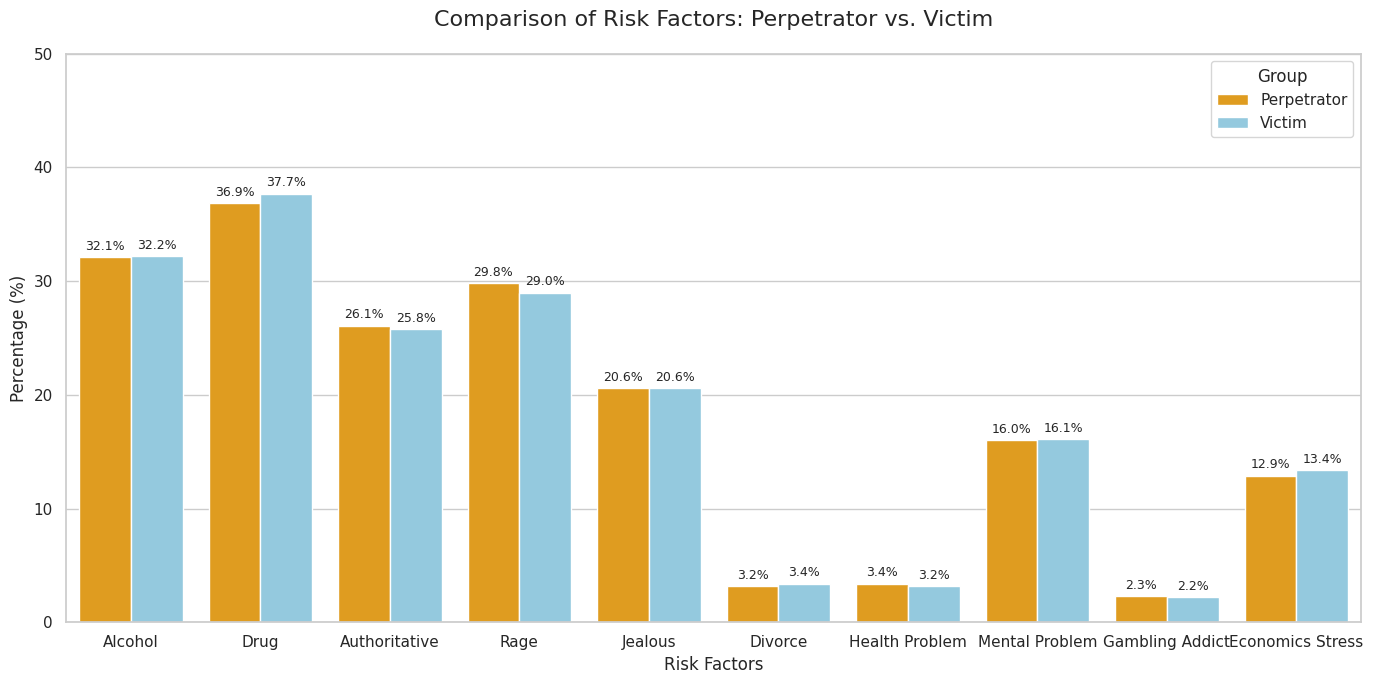

In [ ]:
def get_pct(df, column):
    if column not in df.columns:
        return 0.0
    counts = df[column].value_counts()
    return (counts.get("ใช่", 0) / counts.sum() * 100).round(1)

risks = ["Alcohol", "Drug", "Authoritative", "Rage", "Jealous",
         "Divorce", "Health Problem", "Mental Problem",
         "Gambling Addict", "Economics Stress"]

# 2. Dynamic Data Preparation
rows = []
for col in risks:
    # Calculate for Perpetrators
    perp_val = get_pct(perpetrators_df, col)
    rows.append({'Factor': col, 'Percentage': perp_val, 'Group': 'Perpetrator'})

    # Calculate for Victims
    vic_val = get_pct(victims_df, col)
    rows.append({'Factor': col, 'Percentage': vic_val, 'Group': 'Victim'})

df_plot = pd.DataFrame(rows)

# 3. Plotting
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

colors = {'Perpetrator': "orange", "Victim": "skyblue"}

# Map x to 'Factor' instead of 'key' to show English names
ax = sns.barplot(data=df_plot, x='Factor', y='Percentage', hue='Group', palette=colors)

# 4. Formatting
# If title still shows boxes, you may need to use an English title or check font paths
plt.title('Comparison of Risk Factors: Perpetrator vs. Victim', fontsize=16, pad=20)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.ylim(0, 50)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.legend(title='Group')
plt.tight_layout()
plt.show()

ไม่พบความแตกต่างกันระหว่างปัจจัยความเสี่ยงของ ทั้งฝั่งผู้กระทำและผู้ถูกกระทำ

โดยปัจจัยเสี่ยงอันดับ 3 อันดับแรก คือ สารเสพติด แอลกอฮอล์ และ การใช้ความรุนแรง

> กลุ่มเสี่ยง ของผู้กระทำ ผู้ชาย วัยกลางคน มีปัญหาเรื่องการใช้ สารเสพติด แอลกอฮอล์ โดยส่วนใหญ่เป็นสามีของผู้ถูกกระทำ

> กลุ่มเสี่ยง ของผู้ถูกกระทำ ผู้หญิง วัยกลางคน มีปัญหาเรื่องการใช้ สารเสพติด แอลกอฮอล์

## วิเคราะห์ตามพื้นที่และช่วงเวลา

In [ ]:
incidents_df["Regional"].value_counts()

,count
Regional,
ภาคกลาง,382
ภาคตะวันออกเฉียงเหนือ,205
ภาคเหนือ,164
ภาคใต้,126


In [ ]:
#resetting font due to some bug of present thai font
mpl.rcParams['font.family'] = 'TH Sarabun New'


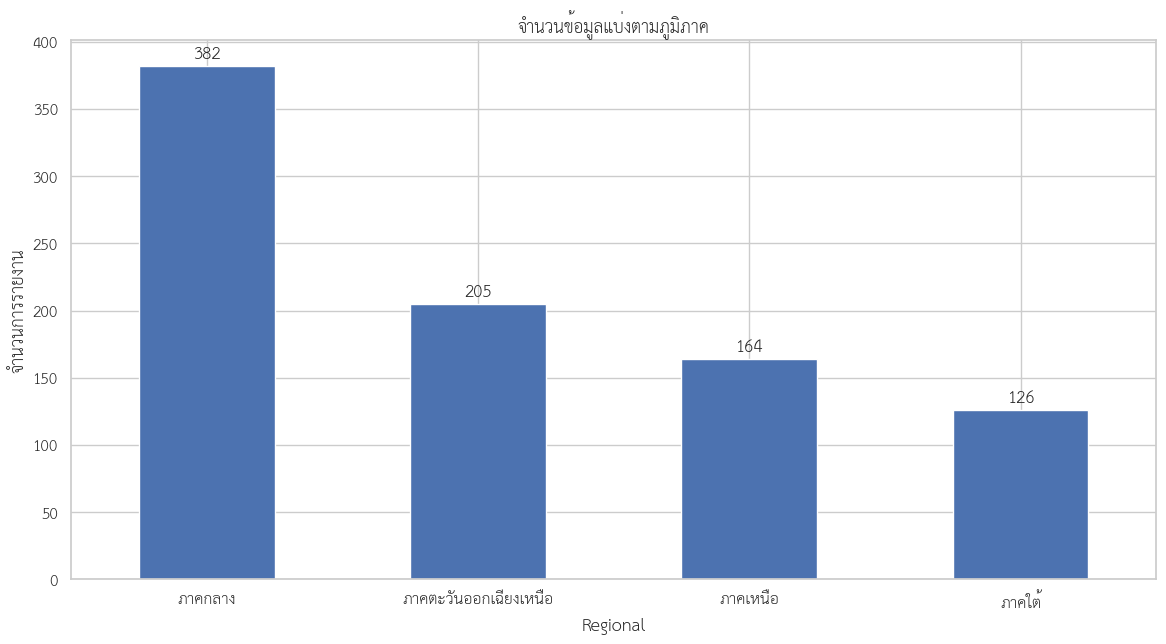

In [ ]:

# Reindex the counts to match this order
counts = incidents_df["Regional"].value_counts()

# Plot
ax = counts.plot(kind='bar', figsize=(14, 7), rot=0)
ax.bar_label(ax.containers[0], padding=3)

plt.title("จำนวนข้อมูลแบ่งตามภูมิภาค")
plt.ylabel("จำนวนการรายงาน")
plt.show()

เหตุการความรุนแรงเกิดมากที่สุดใน  ภาคกลาง > ภาคตะวันออกเฉียงเหนือ  >  ภาคเหนือ  >  ภาคใต้

In [ ]:
incidents_df["Period"].unique()

array(['12:01 – 18:00', '18:01 – 00:00', '06:01 – 12:00', '00:01 – 06:00'],
      dtype=object)

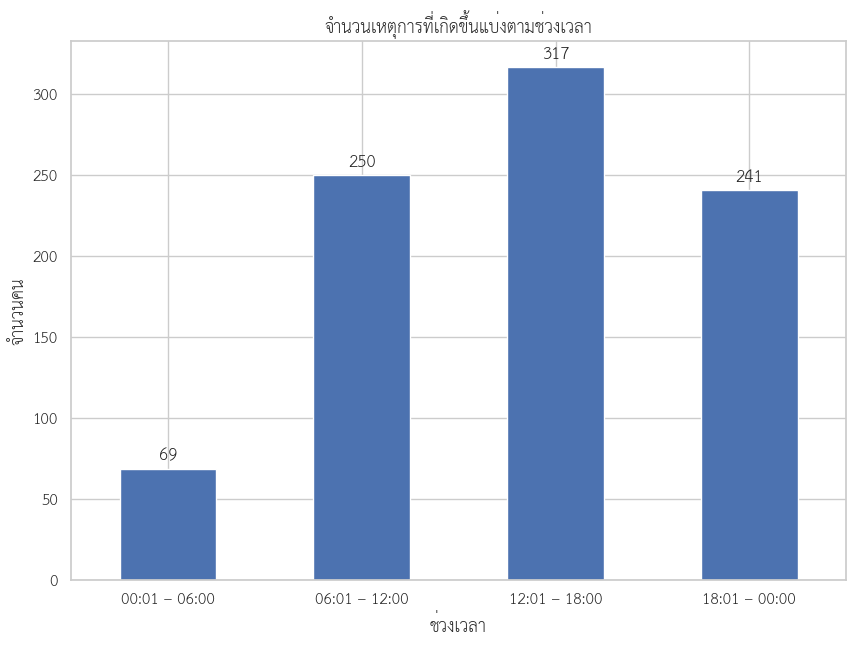

In [ ]:
time_order = [ '00:01 – 06:00',
               '06:01 – 12:00' ,
              '12:01 – 18:00',
              '18:01 – 00:00']

# the counts Province
counts = incidents_df["Period"].value_counts().reindex(time_order)

# Plot
ax = counts.plot(kind='bar', figsize=(10, 7), rot=0)
ax.bar_label(ax.containers[0], padding=3)

plt.title("จำนวนเหตุการที่เกิดขึ้นแบ่งตามช่วงเวลา")
plt.ylabel("จำนวนคน")
plt.xlabel("ช่วงเวลา")
plt.show()

เหตุเกิดในช่วงกลางวันถึงช่วงเย็นมากที่สุด

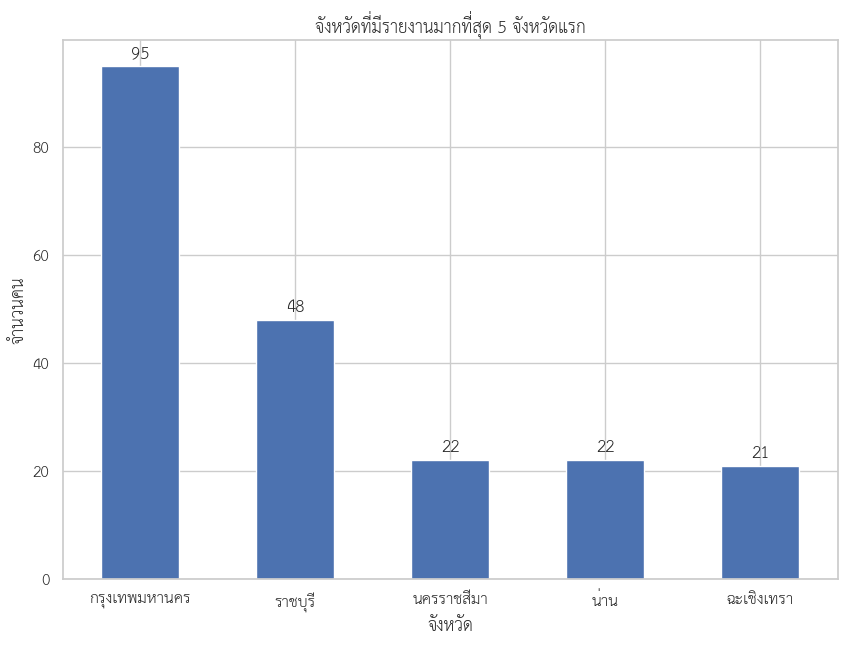

In [ ]:
# the counts Province
counts = incidents_df["Province"].value_counts()

# Plot
ax = counts.head(5).plot(kind='bar', figsize=(10, 7), rot=0)
ax.bar_label(ax.containers[0], padding=3)

plt.title("จังหวัดที่มีรายงานมากที่่สุด 5 จังหวัดแรก")
plt.ylabel("จำนวนคน")
plt.xlabel("จังหวัด")
plt.show()

5 อันดับแรกของจังหวัดที่ได้รับรายงาน คือ กรุงเทพมหานคร ราชบุรี น่าน นครราชสีมา ฉะเชิงเทรา

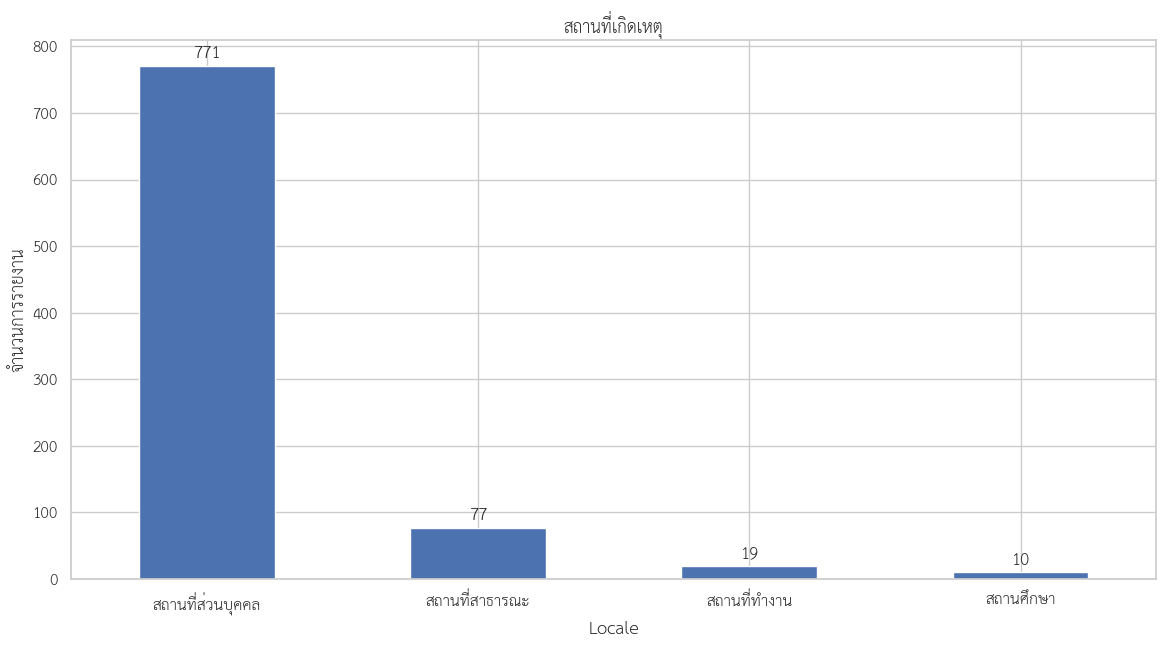

In [ ]:
# Reindex the counts to match this order
counts = incidents_df["Locale"].value_counts()

# Plot
ax = counts.plot(kind='bar', figsize=(14, 7), rot=0)
ax.bar_label(ax.containers[0], padding=3)

plt.title("สถานที่เกิดเหตุ")
plt.ylabel("จำนวนการรายงาน")
plt.show()

เหตุการณ์ส่วนใหญ่เกิดในสถานที่ส่วนบุคคล

In [ ]:
bkk_incidents_df = incidents_df[incidents_df["Province"] == "กรุงเทพมหานคร"]

In [ ]:
bkk_incidents_df.head()

,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,18:01 – 00:00,สถานที่ส่วนบุคคล
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,00:01 – 06:00,สถานที่ส่วนบุคคล


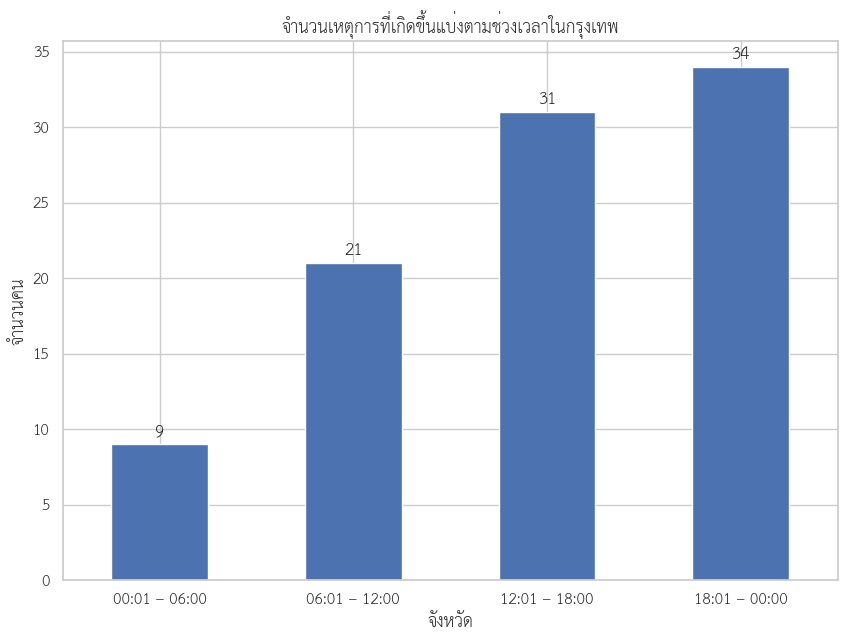

In [ ]:
time_order = [ '00:01 – 06:00',
               '06:01 – 12:00' ,
              '12:01 – 18:00',
              '18:01 – 00:00']

# the counts Province
counts = bkk_incidents_df["Period"].value_counts().reindex(time_order)

# Plot
ax = counts.plot(kind='bar', figsize=(10, 7), rot=0)
ax.bar_label(ax.containers[0], padding=3)

plt.title("จำนวนเหตุการที่เกิดขึ้นแบ่งตามช่วงเวลาในกรุงเทพ")
plt.ylabel("จำนวนคน")
plt.xlabel("จังหวัด")
plt.show()

ในกรุงเทพมีเหตการณ์เกิดขึ้นมากที่สุดช่วงเย็นจนถึงเที่ยงคืน

In [ ]:
# create df count incidents base on province
count_incidents_df = incidents_df["Province"].value_counts()

# # create df count incidents base on province and period during day
count_incidents_df_0060 = incidents_df[incidents_df["Period"]=="00:01 – 06:00"]["Province"].value_counts()
count_incidents_df_6012 = incidents_df[incidents_df["Period"]=="06:01 – 12:00"]["Province"].value_counts()
count_incidents_df_1218 = incidents_df[incidents_df["Period"]=="12:01 – 18:00"]["Province"].value_counts()
count_incidents_df_1800 = incidents_df[incidents_df["Period"]=="18:01 – 00:00"]["Province"].value_counts()

In [ ]:
count_incidents_df

,count
Province,
กรุงเทพมหานคร,95
ราชบุรี,48
นครราชสีมา,22
น่าน,22
ฉะเชิงเทรา,21
...,...
ลำปาง,3
เพชรบุรี,2
สมุทรสงคราม,1


In [ ]:
# Load province of the Thailand centroid GeoJSON
# Data from https://github.com/noppakorn/thailand-map-geojson/blob/7f9f6b67bab80961686430f391e9d3629c184a35/th-adm1-province-centroid.geojson

provinces_geo = gpd.read_file("th-adm1-province-centroid.geojson")
provinces_geo.head()

,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM1ALT1TH,ADM1ALT2TH,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,3.927244,0.275313,Amnat Charoen,อำนาจเจริญ,TH37,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,None,POINT (104.74137 15.89261)
1,1.739908,0.079210,Ang Thong,อ่างทอง,TH15,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,None,POINT (100.34851 14.62354)
2,2.417227,0.131339,Bangkok,กรุงเทพมหานคร,TH10,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,None,POINT (100.62353 13.77183)
3,4.414998,0.340784,Bueng Kan,บึงกาฬ,TH38,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,None,POINT (103.71093 18.14879)
4,8.701860,0.844537,Buri Ram,บุรีรัมย์,TH31,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,None,POINT (102.9567 14.81998)


In [ ]:
# remove all colume not necessary to use

provinces_geo =provinces_geo.drop(columns=['ADM1_REF',
                            'ADM1ALT1EN',
                            'ADM1ALT2EN',
                            'ADM1ALT1TH',
                            'ADM1ALT2TH',
                            'ADM0_EN',
                            'ADM0_TH',
                            'ADM0_PCODE',
                            'date',
                            'validOn',
                            'validTo'])

provinces_geo.head()

,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,geometry
0,3.927244,0.275313,Amnat Charoen,อำนาจเจริญ,TH37,POINT (104.74137 15.89261)
1,1.739908,0.079210,Ang Thong,อ่างทอง,TH15,POINT (100.34851 14.62354)
2,2.417227,0.131339,Bangkok,กรุงเทพมหานคร,TH10,POINT (100.62353 13.77183)
3,4.414998,0.340784,Bueng Kan,บึงกาฬ,TH38,POINT (103.71093 18.14879)
4,8.701860,0.844537,Buri Ram,บุรีรัมย์,TH31,POINT (102.9567 14.81998)


In [ ]:
# Merge them using the name columns
# We use 'ADM1_TH' from the GeoJSON and whatever your Thai column is called in incidents_df
count_incidents_gpd = provinces_geo.merge(
    count_incidents_df,
    left_on='ADM1_TH',
    right_on='Province'
)


count_incidents_df_0060 = provinces_geo.merge(
    count_incidents_df_0060,
    left_on='ADM1_TH',
    right_on='Province'
)


count_incidents_df_6012 = provinces_geo.merge(
    count_incidents_df_6012,
    left_on='ADM1_TH',
    right_on='Province'
)


count_incidents_df_1218 = provinces_geo.merge(
    count_incidents_df_1218,
    left_on='ADM1_TH',
    right_on='Province'
)


count_incidents_df_1800 = provinces_geo.merge(
    count_incidents_df_1800,
    left_on='ADM1_TH',
    right_on='Province'
)


In [ ]:
count_incidents_gpd.head()

,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,geometry,count
0,1.739908,0.079210,Ang Thong,อ่างทอง,TH15,POINT (100.34851 14.62354),10
1,2.417227,0.131339,Bangkok,กรุงเทพมหานคร,TH10,POINT (100.62353 13.77183),95
2,4.414998,0.340784,Bueng Kan,บึงกาฬ,TH38,POINT (103.71093 18.14879),9
3,8.701860,0.844537,Buri Ram,บุรีรัมย์,TH31,POINT (102.9567 14.81998),9
4,4.941453,0.431484,Chachoengsao,ฉะเชิงเทรา,TH24,POINT (101.42538 13.60649),21


In [ ]:
count_incidents_gpd.describe()

,Shape_Leng,Shape_Area,count
count,74.000000,74.000000,74.000000
mean,5.771034,0.570478,11.851351
std,2.640443,0.408374,12.052036
min,1.024202,0.034582,1.000000
25%,4.166395,0.295722,6.000000
50%,5.587321,0.474197,9.000000
75%,7.308579,0.808061,13.000000
max,13.776585,1.900546,95.000000


In [ ]:
Thailandmap

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_5438/38615481.py:3: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_map = gpd.sjoin(Thailandmap, count_incidents_gpd, how="left", predicate="contains")


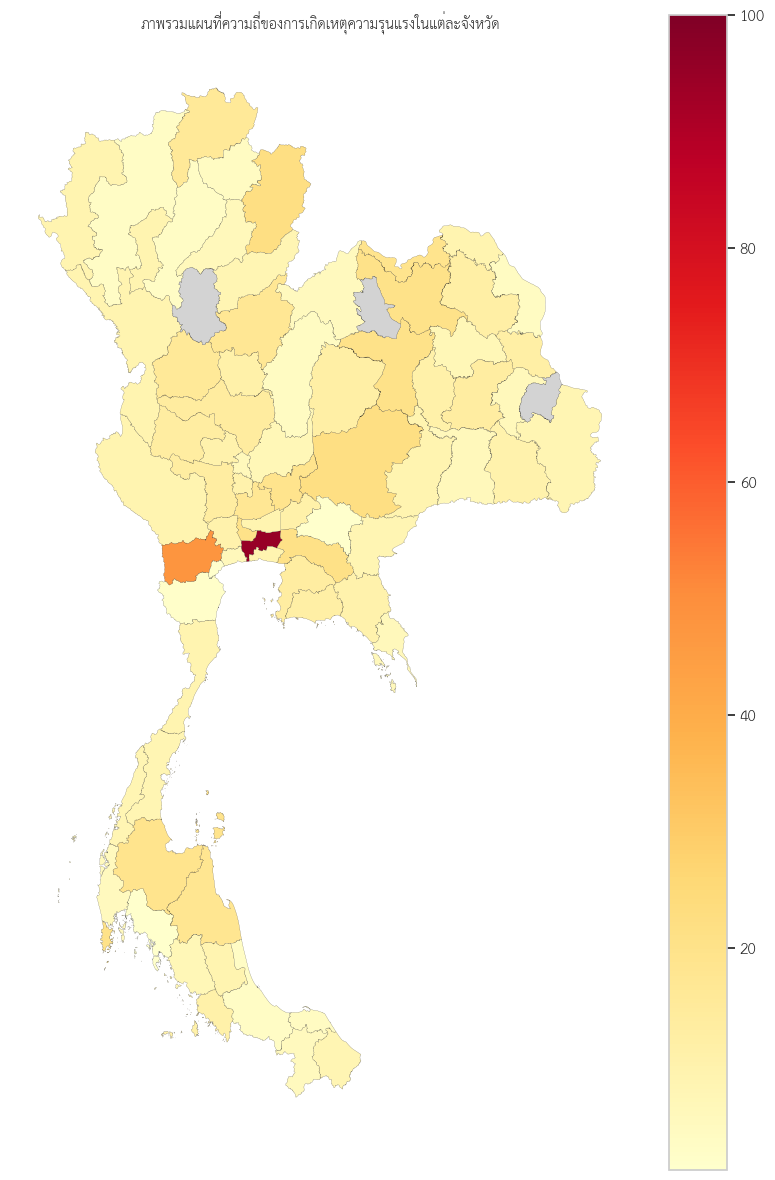

In [ ]:
# 1. Spatial Join: Join the points to the polygons based on location
# This adds the data from your points to the province they sit inside
merged_map = gpd.sjoin(Thailandmap, count_incidents_gpd, how="left", predicate="contains")

# 2. Plot the result
fig, ax = plt.subplots(figsize=(10, 15))

merged_map.plot(
    ax=ax,
    column='count',      # Use the 'count' column from your incident data
    cmap='YlOrRd',
    vmax=100,
    edgecolor='black',
    figsize= (10,10),
    linewidth=0.1,
    legend=True,
    missing_kwds={"color": "lightgrey"} # Provinces with 0 incidents will be grey
)

ax.axis('off')
plt.title("ภาพรวมแผนที่ความถี่ของการเกิดเหตุความรุนแรงในแต่ละจังหวัด", fontsize=10)
plt.show()

> กรุงเทพ เป็นพื้นที่สีแดงเข้มเพียงจุดเดียวที่พุ่งทะลุ 100 เคส/วัน ตามด้วยปริมณฑลและชลบุรีที่เป็นสีส้ม รองลงมาคือหัวเมืองใหญ่อย่างเชียงใหม่และพื้นที่ชายแดนใต้ที่เริ่มเห็นสีเหลืองเข้มชัดขึ้น

/tmp/ipykernel_5438/1325411717.py:18: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_map = gpd.sjoin(Thailandmap, df, how="left", predicate="contains")
/tmp/ipykernel_5438/1325411717.py:18: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_map = gpd.sjoin(Thailandmap, df, how="left", predicate="contains")
/tmp/ipykernel_5438/1325411717.py:18: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_map = gpd.sjoin(Thailandmap, df, how="left", predicate="contains")
/

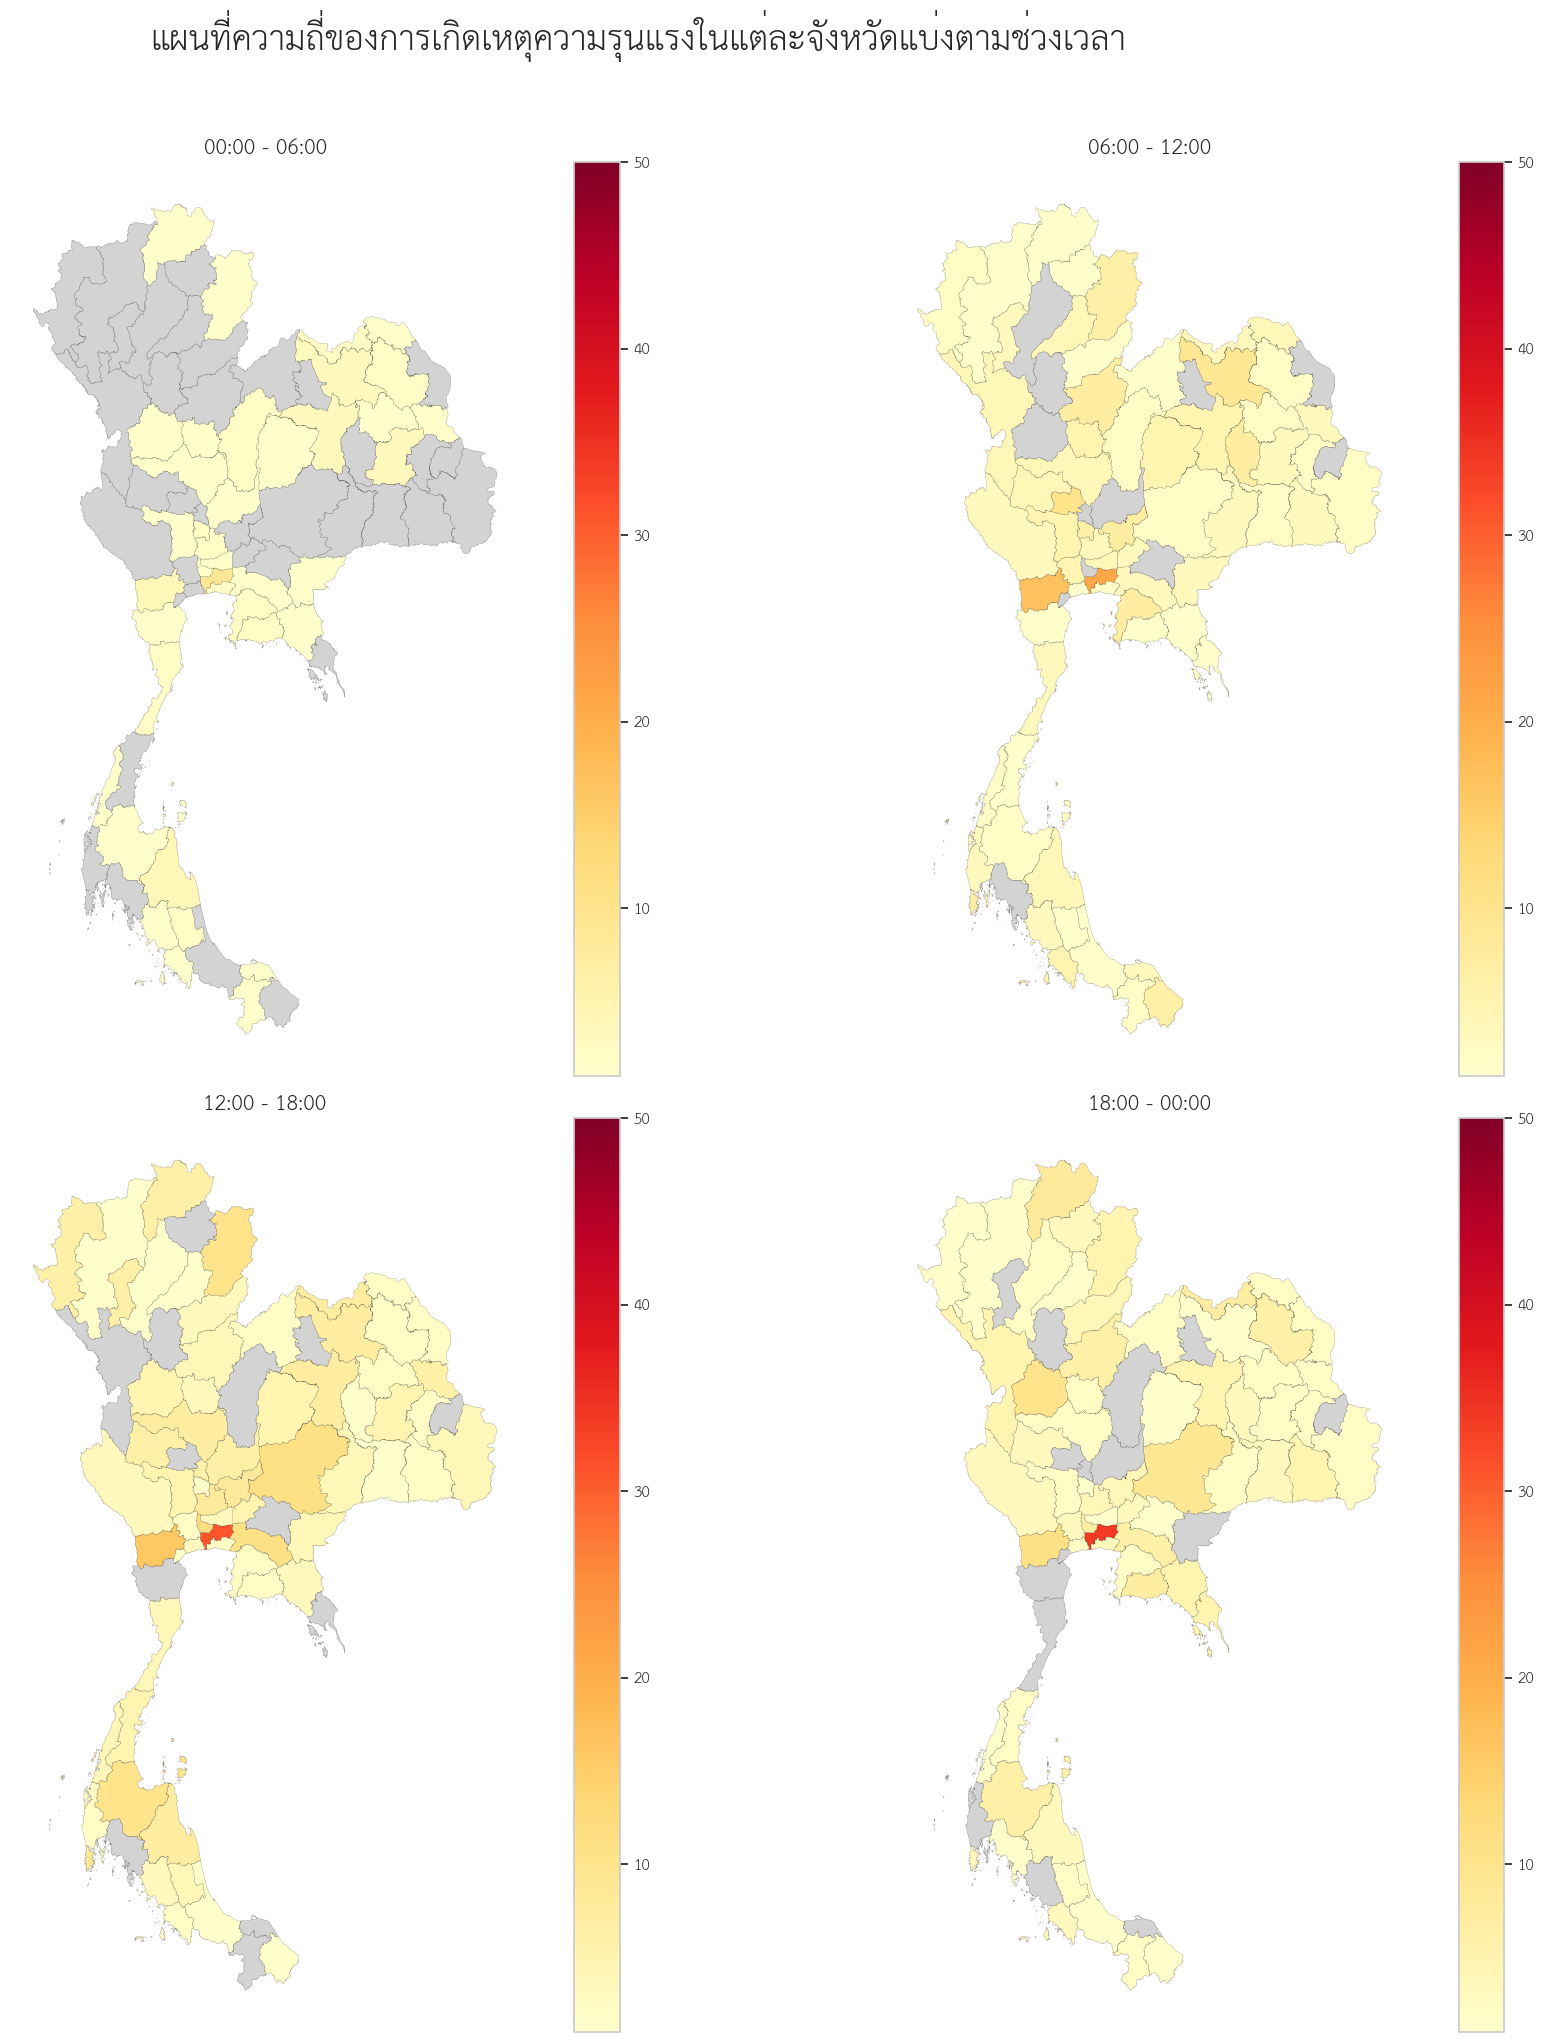

In [ ]:
# subplot 2x2
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()  # Now axes[0], axes[1], axes[2], axes[3]

# List of your dataframes and corresponding titles for the loop
dataframes = [
    count_incidents_df_0060,
    count_incidents_df_6012,
    count_incidents_df_1218,
    count_incidents_df_1800
]

titles = ["00:00 - 06:00", "06:00 - 12:00", "12:00 - 18:00", "18:00 - 00:00"]

# 2. Loop through and plot each map onto the grid
for i, df in enumerate(dataframes):
    # Spatial Join
    merged_map = gpd.sjoin(Thailandmap, df, how="left", predicate="contains")

    # Plotting on the specific subplot axis
    merged_map.plot(
        ax=axes[i],
        column='count',
        cmap='YlOrRd',
        vmax=50,
        edgecolor='black',
        linewidth=0.1,
        legend=True,
        missing_kwds={"color": "lightgrey"}
    )

    # Clean up the look of each subplot
    axes[i].set_title(titles[i], fontsize=15)
    axes[i].axis('off')

# 3. Finalize the layout
plt.suptitle("แผนที่ความถี่ของการเกิดเหตุความรุนแรงในแต่ละจังหวัดแบ่งตามช่วงเวลา", fontsize=24, y=1.02)
plt.tight_layout()
plt.show()

> กรุงเทพ และปริมณฑลคือจุดวิกฤตที่สุด โดยเฉพาะช่วงเย็นถึงเที่ยงคืนที่มีเหตุการณ์หนาแน่นชัดเจนกว่าช่วงอื่น ส่วนช่วงเช้ามืดสถานการณ์จะเบาบางที่สุดในแทบทุกพื้นที่ครับ

In [ ]:
risks = ["Relation",
        "Alcohol",
        "Drug",
        "Authoritative",
        "Rage",
        "Jealous",
        "Divorce",
        "Health Problem",
        "Mental Problem",
        "Gambling Addict",
        "Economics Stress"]

perpetrators_df['count_factor'] = (perpetrators_df[risks] == "ใช่").sum(axis=1)

In [ ]:
perpetrators_df.head()

,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,count_factor
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,61,วัยสูงอายุ 60 ปีขึ้นไป,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,1
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,26,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,1
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,หญิง,55,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,1
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,หญิง,64,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,จดทะเบียนหย่า,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,3
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,ชาย,33,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,3


In [ ]:
perpetrators_df.describe()

,Age,count_factor
count,564.000000,564.000000
mean,40.218085,1.831560
std,12.884938,1.001773
min,10.000000,1.000000
25%,31.000000,1.000000
50%,39.000000,2.000000
75%,48.250000,2.000000
max,84.000000,6.000000


In [ ]:
mpl.rcParams['font.family'] = 'TH Sarabun New'


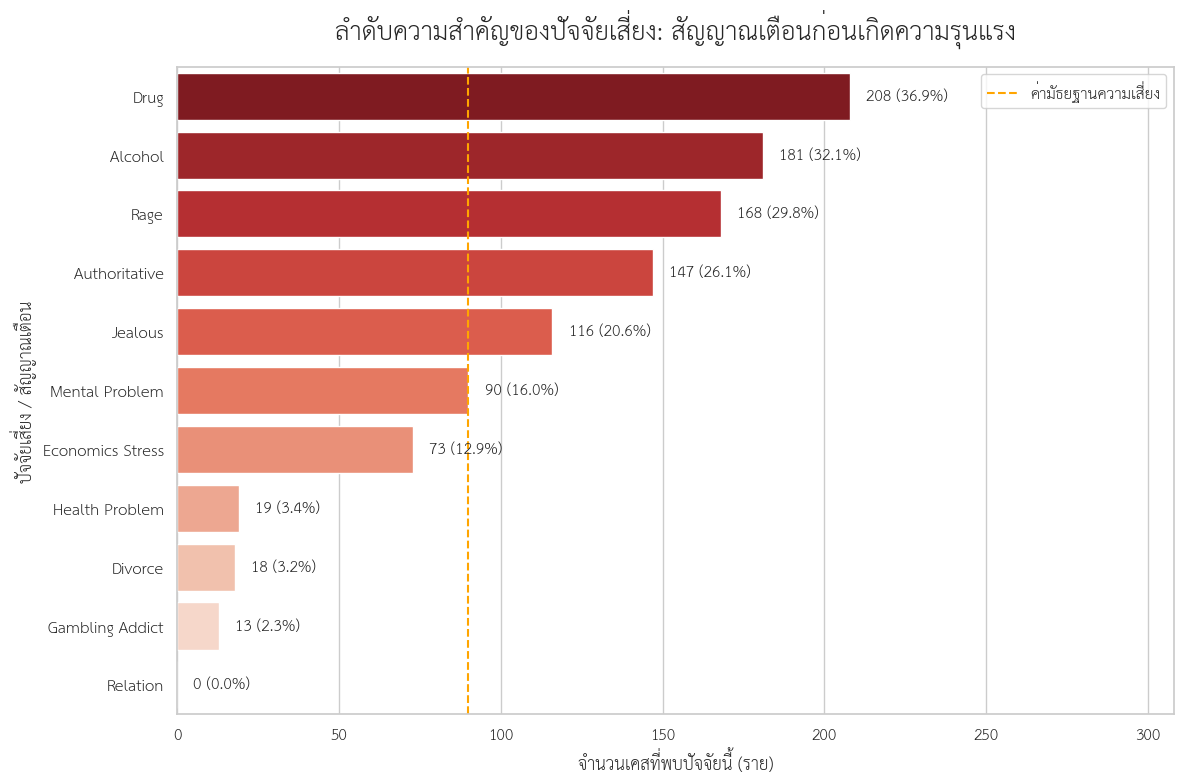

In [ ]:
# 1. เตรียมข้อมูล: นับจำนวน "ใช่" ในแต่ละปัจจัยเสี่ยง
risks = ["Alcohol", "Rage", "Authoritative", "Drug", "Jealous",
         "Mental Problem", "Economics Stress", "Relation",
         "Health Problem", "Divorce", "Gambling Addict"]

# สร้าง Dictionary เก็บผลรวม
risk_counts = {}
for risk in risks:
    # นับเฉพาะแถวที่เป็น "ใช่"
    count = (perpetrators_df[risk] == "ใช่").sum()
    risk_counts[risk] = count

# แปลงเป็น DataFrame และเรียงลำดับ
df_vis = pd.DataFrame(list(risk_counts.items()), columns=['Factor', 'Count'])
df_vis = df_vis.sort_values('Count', ascending=False)

# 2. เริ่มสร้างการแสดงผล (Visualization)
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
mpl.rcParams['font.family'] = 'TH Sarabun New' # Ensure font is set before plotting

# ใช้ Palette สีที่เน้นความวิกฤต (แดงไปเหลือง)
# Add hue='Factor' and legend=False to address the FutureWarning
ax = sns.barplot(x='Count', y='Factor', data=df_vis, palette="Reds_r", hue='Factor', legend=False)

# ใส่ตัวเลขจำนวนและเปอร์เซ็นต์ที่ปลายแท่ง
total = len(perpetrators_df)
for p in ax.patches:
    width = p.get_width()
    percentage = (width / total) * 100
    ax.annotate(f'{int(width)} ({percentage:.1f}%)',
                (width + 5, p.get_y() + p.get_height()/2),
                va='center', fontsize=11, fontweight='bold')

# 3. ตกแต่งเพื่อการสื่อสารเชิงนโยบาย
plt.title("ลำดับความสำคัญของปัจจัยเสี่ยง: สัญญาณเตือนก่อนเกิดความรุนแรง", fontsize=18, pad=20)
plt.xlabel("จำนวนเคสที่พบปัจจัยนี้ (ราย)", fontsize=12)
plt.ylabel("ปัจจัยเสี่ยง / สัญญาณเตือน", fontsize=12)
plt.xlim(0, df_vis['Count'].max() + 100) # เผื่อพื้นที่ให้ตัวเลขท้ายแท่ง

# ไฮไลท์จุดที่ควรทำนโยบายก่อน
plt.axvline(x=df_vis['Count'].median(), color='orange', linestyle='--', label='ค่ามัธยฐานความเสี่ยง')
plt.legend()

plt.tight_layout()
plt.show()

> ปัจจัยที่อยู่ 3 ลำดับแรก (เช่น สุรา, ความโกรธ, การใช้อำนาจ) คือ "จุดคัดกรองสำคัญ" ที่เจ้าหน้าที่หน้างาน (ตำรวจ/นักสังคมสงเคราะห์) ต้องใช้ประเมินความเสี่ยงทันทีที่ได้รับแจ้งเหตุ